<a href="https://colab.research.google.com/github/sgaleanoca/Senales_y_Sistemas/blob/segundo-corte/Segundo_Taller_SyS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Taller 2**

**Nombre:** Santiago Galeano Castaño

## Punto 1.1

### Ejercicios del punto 1.1

- Presente y describa el modelo que utiliza la FFT para el cálculo de los armónicos.

- Realice una comparación del tiempo de cómputo requerido para el cálculo de la transformada discreta de Fourier utilizado la estimación por sumatoria vs la FFT. Pruebe distintos valores de longitud de la señal de entrada (4,8,16,32,64,128,256,512,1024,2048,4096). Presente una gráfica comparativa de los tiempos de ejecución en segundos vs la longitud de la señal de entrada.

- Consulte en qué consiste la frecuencia de -3dB y su relación con las frecuencias de corte en el filtrado espectral de señales.

- Implemente un filtro pasa bajas, un pasa altas, un pasa bandas, y un rechaza bandas utilizando la FFT y la iFFT sobre 5 segundos de su canción favorita de YouTube.

- Diseñe e implemente un detector de género musical, que permita diferenciar entre dos tipos de género. Para ello, construya una base de datos con al menos 50 registros por género musical, de 5 segundos cada uno, y luego implemente un código que permita recibir un nuevo registro músical de 5 segundos para detectar el género de la canción a partir de los vecinos más cercanos según la distancia Euclídea entre la magnitud del espectro de Fourier del nuevo registro (ver [clasificador KNN](https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm)), y las magnitudes de los espectros de la base de datos construida (Ver [Cuaderno YouTube Download/Detector](https://github.com/amalvarezme/SenalesSistemas/blob/master/3_SerieyTransformadaFourier/youtube_detector.ipynb)).

**Nota**: Utilice su IA preferida para describir y entender apropiadamente los códigos guía.

### Solución 1

Presente y describa el modelo que utiliza la FFT para el cálculo de los armónicos.

<>:53: SyntaxWarning: invalid escape sequence '\l'
<>:53: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-4139752759.py:53: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(N_values, times_fft, 'b^-', label='FFT (Numpy - $O(N \log N)$)')


N       Tiempo DFT (s)      Tiempo FFT (s)      
------------------------------------------------
4       0.00010144          0.00005476          
8       0.00006935          0.00002867          
16      0.00007065          0.00002343          
32      0.00073878          0.00003561          
64      0.00212991          0.00005622          
128     0.00209078          0.00004976          
256     0.00384020          0.00012606          
512     0.01444882          0.00009456          
1024    0.05475536          0.00010613          
2048    0.19575923          0.00013339          
4096    0.66696593          0.00016902          


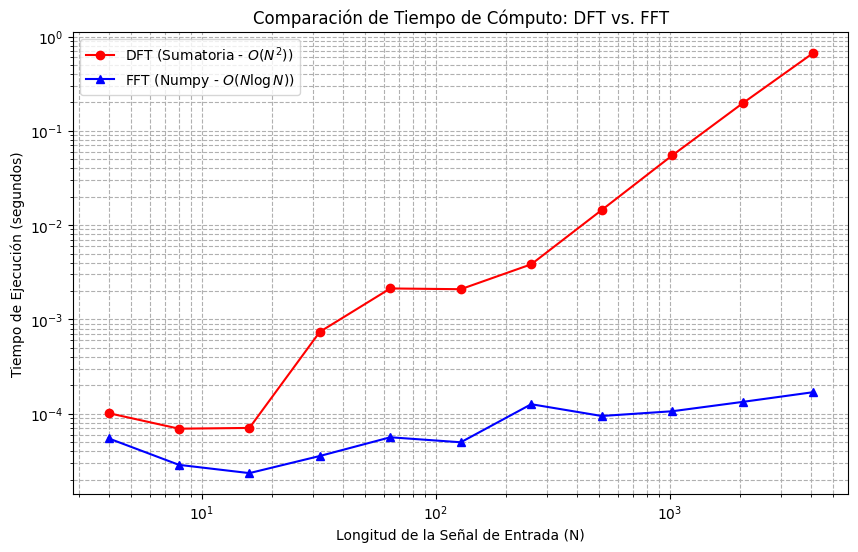

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt

# Longitudes de la señal (N debe ser potencia de 2 para la FFT clásica)
N_values = [4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]

# Almacenar tiempos de ejecución
times_dft = []
times_fft = []

# --- 1. Implementación de la DFT por Sumatoria (O(N^2)) ---
def dft_manual(x):
    N = len(x)
    # Crea la matriz de pesos de DFT (los exponenciales)
    n = np.arange(N)
    k = n.reshape((N, 1))
    e_arg = np.exp(-2j * np.pi * k * n / N)
    # Multiplica la señal por los pesos y suma
    return np.dot(e_arg, x)

# --- 2. Implementación de la FFT de Numpy (O(N log N)) ---
def fft_numpy(x):
    return np.fft.fft(x)

# ----------------- EJECUCIÓN Y CÁLCULO DE TIEMPOS -----------------
for N in N_values:
    # Generar una señal aleatoria de longitud N
    x = np.random.rand(N)

    # 1. Medir tiempo de la DFT Manual (Sumatoria)
    start_time = time.perf_counter()
    _ = dft_manual(x)
    end_time = time.perf_counter()
    times_dft.append(end_time - start_time)

    # 2. Medir tiempo de la FFT de Numpy
    start_time = time.perf_counter()
    _ = fft_numpy(x)
    end_time = time.perf_counter()
    times_fft.append(end_time - start_time)

# ----------------- RESULTADOS EN TABLA -----------------
print(f"{'N':<8}{'Tiempo DFT (s)':<20}{'Tiempo FFT (s)':<20}")
print("-" * 48)
for n, tdft, tfft in zip(N_values, times_dft, times_fft):
    print(f"{n:<8}{tdft:<20.8f}{tfft:<20.8f}")


# ----------------- GRÁFICA COMPARATIVA -----------------
plt.figure(figsize=(10, 6))
plt.plot(N_values, times_dft, 'ro-', label='DFT (Sumatoria - $O(N^2)$)')
plt.plot(N_values, times_fft, 'b^-', label='FFT (Numpy - $O(N \log N)$)')

plt.title('Comparación de Tiempo de Cómputo: DFT vs. FFT')
plt.xlabel('Longitud de la Señal de Entrada (N)')
plt.ylabel('Tiempo de Ejecución (segundos)')
plt.yscale('log') # Escala logarítmica para apreciar la diferencia
plt.xscale('log') # Escala logarítmica para el eje x
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()


### Solución 2

Realice una comparación del tiempo de cómputo requerido para el cálculo de la transformada discreta de Fourier utilizado la estimación por sumatoria vs la FFT. Pruebe distintos valores de longitud de la señal de entrada (4,8,16,32,64,128,256,512,1024,2048,4096). Presente una gráfica comparativa de los tiempos de ejecución en segundos vs la longitud de la señal de entrada.

<>:55: SyntaxWarning: invalid escape sequence '\l'
<>:66: SyntaxWarning: invalid escape sequence '\l'
<>:55: SyntaxWarning: invalid escape sequence '\l'
<>:66: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-3560397499.py:55: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(N_valores, tiempos_fft, 'bo-', label='FFT ($O(N \log N)$)', markersize=8)
/tmp/ipython-input-3560397499.py:66: SyntaxWarning: invalid escape sequence '\l'
  plt.loglog(N_valores, tiempos_fft, 'bo-', label='FFT ($O(N \log N)$)', markersize=8)


Iniciando benchmark... (La DFT puede tardar varios minutos para N >= 2048)
N =    4 | Tiempo DFT:   0.000066 s | Tiempo FFT:   0.001425 s
N =    8 | Tiempo DFT:   0.000105 s | Tiempo FFT:   0.000026 s
N =   16 | Tiempo DFT:   0.000412 s | Tiempo FFT:   0.000019 s
N =   32 | Tiempo DFT:   0.001503 s | Tiempo FFT:   0.000020 s
N =   64 | Tiempo DFT:   0.005863 s | Tiempo FFT:   0.000031 s
N =  128 | Tiempo DFT:   0.023889 s | Tiempo FFT:   0.000079 s
N =  256 | Tiempo DFT:   0.096196 s | Tiempo FFT:   0.000077 s
N =  512 | Tiempo DFT:   0.396183 s | Tiempo FFT:   0.000121 s
N = 1024 | Tiempo DFT:   1.537889 s | Tiempo FFT:   0.000106 s
N = 2048 | Tiempo DFT:   6.774287 s | Tiempo FFT:   0.000204 s
N = 4096 | Tiempo DFT:  25.958771 s | Tiempo FFT:   0.000238 s
Benchmark completado.


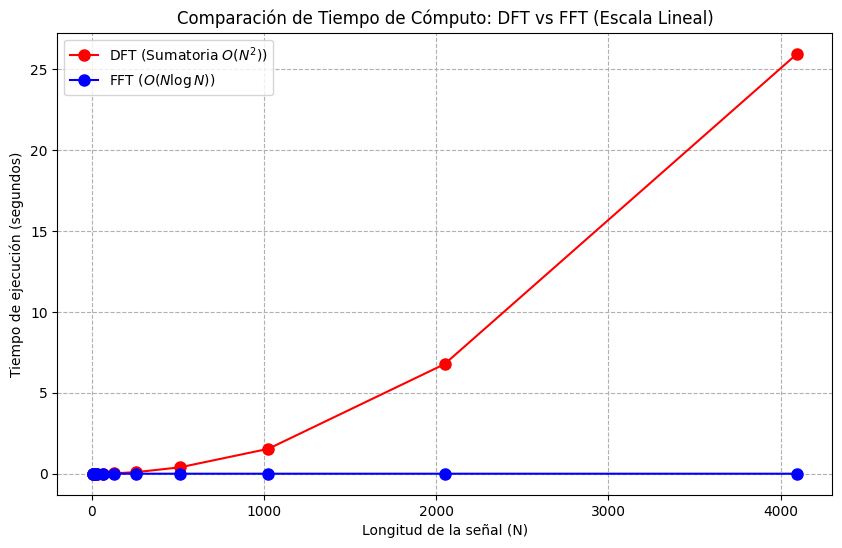

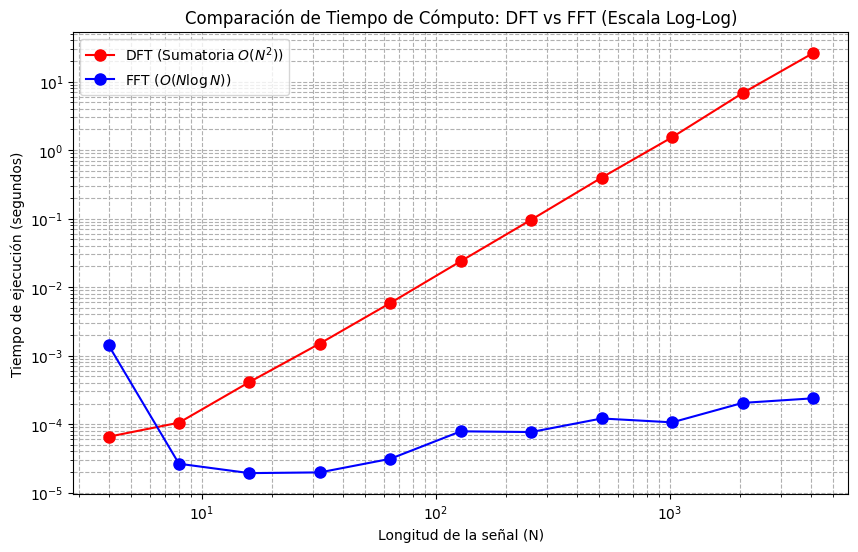

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt

def dft_sumatoria(x):
    # Calcula la DFT usando la sumatoria directa (complejidad O(N^2)).
    N = len(x)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        for n in range(N):
            # Factor de 'twiddle' (W_N)
            twiddle = np.exp(-2j * np.pi * k * n / N)
            X[k] += x[n] * twiddle
    return X

# --- Parámetros de la simulación ---
N_valores = [4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]
tiempos_dft = []
tiempos_fft = []

print("Iniciando benchmark... (La DFT puede tardar varios minutos para N >= 2048)")

# --- Bucle de Banchmarking ---
for N in N_valores:
    # 1. Generar señal de entrada aleatoria
    x = np.random.rand(N)

    # 2. Medir tiempo de la DFT por sumatoria
    # --- ¡CUIDADO! Esto será MUY lento para N grande ---
    # Para N=4096, puede tomar varios minutos.
    start_time_dft = time.time()
    dft_sumatoria(x)
    end_time_dft = time.time()
    tiempo_dft_actual = end_time_dft - start_time_dft
    tiempos_dft.append(tiempo_dft_actual)

    # 3. Medir tiempo de la FFT (implementación optimizada de NumPy)
    start_time_fft = time.time()
    np.fft.fft(x)
    end_time_fft = time.time()
    tiempo_fft_actual = end_time_fft - start_time_fft
    tiempos_fft.append(tiempo_fft_actual)

    print(f"N = {N:4d} | Tiempo DFT: {tiempo_dft_actual:10.6f} s | Tiempo FFT: {tiempo_fft_actual:10.6f} s")

print("Benchmark completado.")

# --- Generación de Gráficas ---

# 1. Gráfica Lineal
plt.figure(figsize=(10, 6))
plt.plot(N_valores, tiempos_dft, 'ro-', label='DFT (Sumatoria $O(N^2)$)', markersize=8)
plt.plot(N_valores, tiempos_fft, 'bo-', label='FFT ($O(N \log N)$)', markersize=8)
plt.xlabel('Longitud de la señal (N)')
plt.ylabel('Tiempo de ejecución (segundos)')
plt.title('Comparación de Tiempo de Cómputo: DFT vs FFT (Escala Lineal)')
plt.legend()
plt.grid(True, which="both", linestyle='--')
plt.show()

# 2. Gráfica Log-Log (Mejor para ver las tendencias de complejidad)
plt.figure(figsize=(10, 6))
plt.loglog(N_valores, tiempos_dft, 'ro-', label='DFT (Sumatoria $O(N^2)$)', markersize=8)
plt.loglog(N_valores, tiempos_fft, 'bo-', label='FFT ($O(N \log N)$)', markersize=8)
plt.xlabel('Longitud de la señal (N)')
plt.ylabel('Tiempo de ejecución (segundos)')
plt.title('Comparación de Tiempo de Cómputo: DFT vs FFT (Escala Log-Log)')
plt.legend()
plt.grid(True, which="both", linestyle='--')
plt.show()

### Solución 3

Consulte en qué consiste la frecuencia de -3dB y su relación con las frecuencias de corte en el filtrado espectral de señales.


### Frecuencia de -3 dB y su relación con las frecuencias de corte

En el análisis de señales y sistemas, la **frecuencia de -3 dB** es aquella en la cual la potencia de la señal de salida de un sistema o filtro se reduce a la mitad respecto a su valor máximo.  

La expresión *–3 dB* proviene de la escala logarítmica de decibelios, donde una atenuación de 3 decibelios equivale aproximadamente a una reducción de la potencia al **50%** del valor máximo.

Matemáticamente, si la magnitud de la respuesta en frecuencia del sistema es \( |H(f)| \), la frecuencia de –3 dB se cumple cuando:

$$
|H(f_c)| = \frac{1}{\sqrt{2}} |H_{\text{max}}|
$$

donde:  
- \( fc \) es la **frecuencia de corte** o **frecuencia de –3 dB**,  
- \( |Hmax|\) → ganancia máxima del sistema.


# Relación con las frecuencias de corte

En el **filtrado espectral de señales**, las **frecuencias de corte** son los puntos que delimitan el paso o rechazo de un filtro.  
Estas se definen justamente en el punto donde la magnitud cae **3 dB por debajo** del valor máximo de ganancia.

Por ejemplo:

- En un **filtro pasa bajos**, la frecuencia de corte \( f_c \) marca el límite entre la banda que se deja pasar y la que se atenúa.  
- En un **filtro pasa banda**, existen **dos frecuencias de –3 dB**:

$$
f_{c1} \text{ (frecuencia de corte inferior)} \quad \text{y} \quad f_{c2} \text{ (frecuencia de corte superior)}
$$

Estas dos frecuencias delimitan el rango de frecuencias que pasan sin atenuarse significativamente.


# Interpretación práctica

La caída de –3 dB corresponde a una reducción de potencia al 50% o de amplitud a aproximadamente el **70.7%** del valor máximo:

$$
\frac{|H(f_c)|}{|H_{\text{max}}|} = 0.707
$$

Por eso, en ingeniería de señales, la frecuencia de –3 dB se adopta como un **punto de referencia estándar** para definir el ancho de banda efectivo de un sistema o filtro.

### Solución 4

Implemente un filtro pasa bajas, un pasa altas, un pasa bandas, y un rechaza bandas utilizando la FFT y la iFFT sobre 5 segundos de su canción favorita de YouTube.

In [4]:
pip install yt-dlp librosa numpy scipy matplotlib

Descargando audio de https://www.youtube.com/watch?v=zZPvME8H2Oo...
'fiesta_pagana.wav' ya existe, saltando descarga.
Cargando 5s de audio desde 108s...
Audio cargado. Tasa de muestreo: 48000 Hz. Muestras: 240000
Filtros aplicados en el dominio de la frecuencia.
Generando gráficas del espectro...


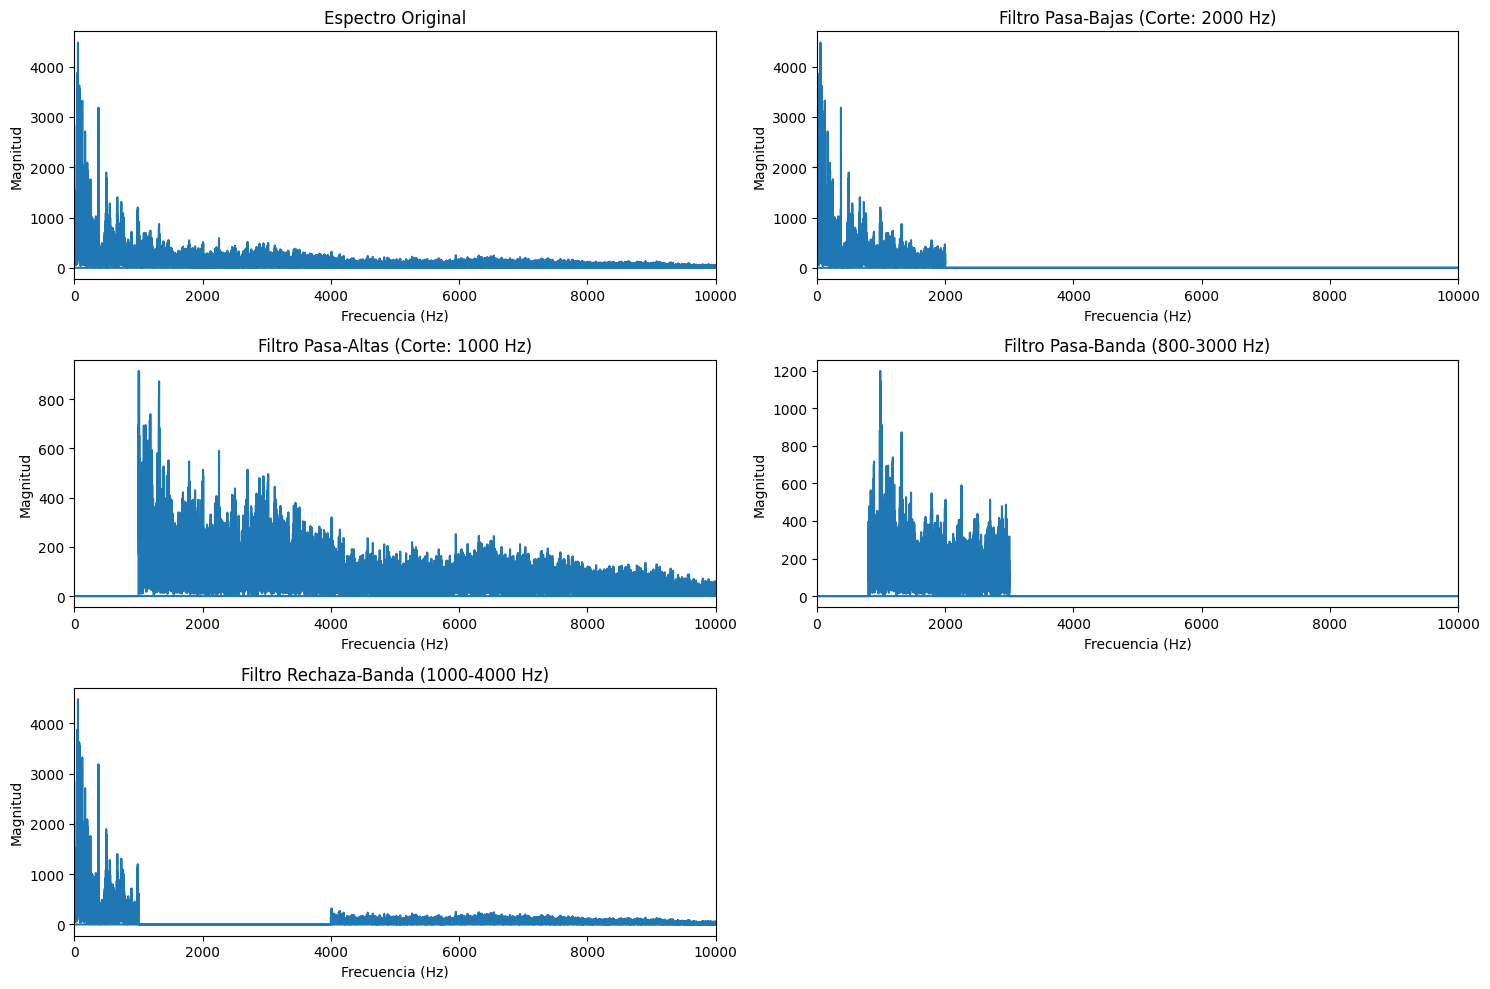

Archivo guardado: fiesta_pasabajas.wav
Archivo guardado: fiesta_pasaaltas.wav
Archivo guardado: fiesta_pasabanda.wav
Archivo guardado: fiesta_rechazabanda.wav
Archivo guardado: fiesta_original_corte.wav


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# IMPORTS - Librerías necesarias para procesamiento de audio y gráficas
# ═══════════════════════════════════════════════════════════════════════════
import os
import numpy as np
import librosa
import yt_dlp
from scipy.io.wavfile import write
from scipy.fft import fft, ifft, fftfreq
import matplotlib.pyplot as plt

# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN - Parámetros del video y segmento de audio a procesar
# ═══════════════════════════════════════════════════════════════════════════
VIDEO_URL = 'https://www.youtube.com/watch?v=zZPvME8H2Oo' # Fiesta Pagana (Audio Oficial)
START_TIME_S = 1 * 60 + 48  # 1:48
DURATION_S = 5
AUDIO_FILENAME = 'fiesta_pagana.wav'

# ═══════════════════════════════════════════════════════════════════════════
# FRECUENCIAS DE CORTE - Límites para los diferentes tipos de filtros
# ═══════════════════════════════════════════════════════════════════════════
CUTOFF_LOW = 2000
CUTOFF_HIGH = 1000
CUTOFF_BAND_L = 800
CUTOFF_BAND_H = 3000
CUTOFF_REJECT_L = 1000
CUTOFF_REJECT_H = 4000

# ═══════════════════════════════════════════════════════════════════════════
# DESCARGA DE AUDIO - Obtiene el audio del video de YouTube en formato WAV
# ═══════════════════════════════════════════════════════════════════════════
def descargar_audio():
    print(f"Descargando audio de {VIDEO_URL}...")
    ydl_opts = {
        'format': 'bestaudio/best',
        'postprocessors': [{
            'key': 'FFmpegExtractAudio',
            'preferredcodec': 'wav',
            'preferredquality': '192',
        }],
        'outtmpl': AUDIO_FILENAME.replace('.wav', ''),
    }
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        if not os.path.exists(AUDIO_FILENAME):
            ydl.download([VIDEO_URL])
        else:
            print(f"'{AUDIO_FILENAME}' ya existe, saltando descarga.")

# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN DE ESPECTROS - Crea gráficas comparativas de los filtros
# ═══════════════════════════════════════════════════════════════════════════
def plot_spectra(xf, yf_orig, yf_low, yf_high, yf_band, yf_reject, sr):
    print("Generando gráficas del espectro...")
    plt.figure(figsize=(15, 10))

    # Limitar el eje X a la mitad del espectro (Teorema de Nyquist)
    # y un poco más acotado para ver detalles (ej. 10000 Hz)
    max_freq_to_plot = min(sr / 2, 10000)

    # 1. Espectro Original
    plt.subplot(3, 2, 1)
    plt.plot(xf, np.abs(yf_orig))
    plt.title('Espectro Original')
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Magnitud')
    plt.xlim(0, max_freq_to_plot)

    # 2. Pasa-bajas
    plt.subplot(3, 2, 2)
    plt.plot(xf, np.abs(yf_low))
    plt.title(f'Filtro Pasa-Bajas (Corte: {CUTOFF_LOW} Hz)')
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Magnitud')
    plt.xlim(0, max_freq_to_plot)

    # 3. Pasa-altas
    plt.subplot(3, 2, 3)
    plt.plot(xf, np.abs(yf_high))
    plt.title(f'Filtro Pasa-Altas (Corte: {CUTOFF_HIGH} Hz)')
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Magnitud')
    plt.xlim(0, max_freq_to_plot)

    # 4. Pasa-banda
    plt.subplot(3, 2, 4)
    plt.plot(xf, np.abs(yf_band))
    plt.title(f'Filtro Pasa-Banda ({CUTOFF_BAND_L}-{CUTOFF_BAND_H} Hz)')
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Magnitud')
    plt.xlim(0, max_freq_to_plot)

    # 5. Rechaza-banda
    plt.subplot(3, 2, 5)
    plt.plot(xf, np.abs(yf_reject))
    plt.title(f'Filtro Rechaza-Banda ({CUTOFF_REJECT_L}-{CUTOFF_REJECT_H} Hz)')
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Magnitud')
    plt.xlim(0, max_freq_to_plot)

    plt.tight_layout() # Ajusta las gráficas para que no se solapen
    plt.show() # Muestra la ventana con las gráficas

# ═══════════════════════════════════════════════════════════════════════════
# PROCESAMIENTO Y FILTRADO - Aplica filtros de frecuencia al audio
# ═══════════════════════════════════════════════════════════════════════════
def filtrar_audio():
    # ────────────────────────────────────────────────────────────────────────
    # CARGA DE AUDIO - Lee un segmento específico del archivo WAV
    # ────────────────────────────────────────────────────────────────────────
    print(f"Cargando {DURATION_S}s de audio desde {START_TIME_S}s...")
    y, sr = librosa.load(
        AUDIO_FILENAME,
        sr=None,
        offset=START_TIME_S,
        duration=DURATION_S
    )
    print(f"Audio cargado. Tasa de muestreo: {sr} Hz. Muestras: {len(y)}")

    # ────────────────────────────────────────────────────────────────────────
    # TRANSFORMADA DE FOURIER - Convierte el audio al dominio de frecuencia
    # ────────────────────────────────────────────────────────────────────────
    N = len(y)
    yf = fft(y)
    xf = fftfreq(N, 1 / sr)

    # ────────────────────────────────────────────────────────────────────────
    # APLICACIÓN DE FILTROS - Elimina o conserva frecuencias específicas
    # ────────────────────────────────────────────────────────────────────────
    yf_low = np.copy(yf)
    yf_high = np.copy(yf)
    yf_band = np.copy(yf)
    yf_reject = np.copy(yf)

    # Pasa-bajas: Solo deja frecuencias por debajo del corte
    yf_low[np.abs(xf) > CUTOFF_LOW] = 0

    # Pasa-altas: Solo deja frecuencias por encima del corte
    yf_high[np.abs(xf) < CUTOFF_HIGH] = 0

    # Pasa-banda: Solo deja frecuencias dentro del rango
    yf_band[(np.abs(xf) < CUTOFF_BAND_L) | (np.abs(xf) > CUTOFF_BAND_H)] = 0

    # Rechaza-banda: Elimina frecuencias dentro del rango
    yf_reject[(np.abs(xf) > CUTOFF_REJECT_L) & (np.abs(xf) < CUTOFF_REJECT_H)] = 0

    print("Filtros aplicados en el dominio de la frecuencia.")

    # ────────────────────────────────────────────────────────────────────────
    # VISUALIZACIÓN - Muestra gráficas comparativas de los espectros
    # ────────────────────────────────────────────────────────────────────────
    plot_spectra(xf, yf, yf_low, yf_high, yf_band, yf_reject, sr)

    # ────────────────────────────────────────────────────────────────────────
    # TRANSFORMADA INVERSA - Convierte de vuelta al dominio del tiempo
    # ────────────────────────────────────────────────────────────────────────
    y_low = np.real(ifft(yf_low))
    y_high = np.real(ifft(yf_high))
    y_band = np.real(ifft(yf_band))
    y_reject = np.real(ifft(yf_reject))

    # ────────────────────────────────────────────────────────────────────────
    # GUARDADO DE ARCHIVOS - Normaliza y exporta los audios filtrados
    # ────────────────────────────────────────────────────────────────────────
    def guardar_wav(filename, y_signal, sr):
        max_val = np.max(np.abs(y_signal))
        if max_val > 0:
            y_norm = y_signal / max_val
        else:
            y_norm = y_signal
        y_int16 = np.int16(y_norm * 32767)
        write(filename, sr, y_int16)
        print(f"Archivo guardado: {filename}")

    guardar_wav('fiesta_pasabajas.wav', y_low, sr)
    guardar_wav('fiesta_pasaaltas.wav', y_high, sr)
    guardar_wav('fiesta_pasabanda.wav', y_band, sr)
    guardar_wav('fiesta_rechazabanda.wav', y_reject, sr)
    guardar_wav('fiesta_original_corte.wav', y, sr)

# ═══════════════════════════════════════════════════════════════════════════
# EJECUCIÓN PRINCIPAL - Punto de entrada del programa
# ═══════════════════════════════════════════════════════════════════════════
if __name__ == "__main__":
    descargar_audio()
    filtrar_audio()

## Punto 1.2

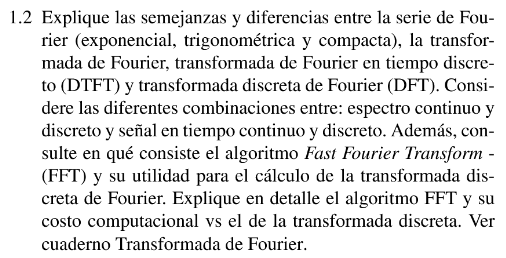

### 1. Series de Fourier (Exponencial, Trigonométrica y Compacta)

Las Series de Fourier se utilizan para representar señales periódicas como una suma de senos y cosenos (o exponenciales complejas).

* **Serie de Fourier Trigonométrica:** Representa una señal periódica $x(t)$ con periodo $T_0$ como:
  $$ x(t)=a0​+∑n=1∞​(an​cos(nω0​t)+bn​sin(nω0​t))$$ Donde $ω0​=2π/T0$​ es la frecuencia fundamental, y los coeficientes $a0​,an​,bn$​ se calculan mediante integrales.
    * **Espectro:** Discreto y de amplitud real (o fase y magnitud).

* **Serie de Fourier Exponencial:** Es una forma más compacta y matemáticamente conveniente, usando la identidad de Euler ($e^{j\theta} = \cos\theta + j\sin\theta$):
  $x(t) = \sum_{n=-\infty}^{\infty} c_n e^{j n \omega_0 t}$
  Donde los coeficientes complejos $c_n$ se calculan mediante:
  $c_n = \frac{1}{T_0} \int_{T_0} x(t) e^{-j n \omega_0 t} dt$
  Existe una relación directa entre $c_n$ y $a_n, b_n$.
    * **Espectro:** Discreto y complejo (magnitud y fase).

* **Serie de Fourier Compacta (o Armónica):** Es una variante de la trigonométrica que combina los términos de seno y coseno en una única onda sinusoidal con fase:
  $x(t) = C_0 + \sum_{n=1}^{\infty} C_n \cos(n\omega_0 t + \phi_n)$
  Donde $C_0 = a_0$, $C_n = \sqrt{a_n^2 + b_n^2}$ y $\phi_n = \arctan(-b_n/a_n)$.
    * **Espectro:** Discreto y de amplitud real (magnitud y fase).

**Similitudes:**
* Todas representan señales periódicas.
* Todas descomponen la señal en componentes armónicos (múltiplos de una frecuencia fundamental).
* Producen un espectro discreto.

**Diferencias:**
* Forma matemática de los términos (senos/cosenos vs. exponenciales complejas).
* Naturaleza de los coeficientes (reales para trigonométrica/compacta, complejos para exponencial).
* La exponencial es la más fundamental y de la que se derivan las otras.

### 2. Transformada de Fourier (FT)

La Transformada de Fourier extiende el concepto de la Serie de Fourier a señales no periódicas y de energía finita en tiempo continuo. Transforma una señal del dominio del tiempo al dominio de la frecuencia.

* **Definición:**
    $X(j\omega) = \mathcal{F}\{x(t)\} = \int_{-\infty}^{\infty} x(t) e^{-j\omega t} dt$
* **Espectro:** Continuo y complejo (magnitud y fase).
* **Señal en el Tiempo:** Continua.
* **Utilidad:** Análisis de señales continuas, filtros, sistemas LTI.



### 3. Transformada de Fourier en Tiempo Discreto (DTFT)

La DTFT es la transformada de Fourier para señales discretas y no periódicas.

* **Definición:** Para una secuencia discreta $x[n]$:
  $X(e^{j\omega}) = \mathcal{F}\{x[n]\} = \sum_{n=-\infty}^{\infty} x[n] e^{-j\omega n}$
* **Espectro:** Continuo (en la variable $\omega$, que ahora es una frecuencia normalizada), periódico (con periodo $2\pi$) y complejo.
* **Señal en el Tiempo:** Discreta.
* **Utilidad:** Análisis de señales discretas, diseño de filtros digitales.

### 4. Transformada Discreta de Fourier (DFT)

La DFT es la versión discreta de la DTFT, adecuada para el procesamiento digital por computadora. Opera sobre una secuencia discreta *y finita* de muestras, y el resultado es también una secuencia discreta y finita de coeficientes de frecuencia.

* **Definición:** Para una secuencia $x[n]$ de longitud $N$:
  $X[k] = \sum_{n=0}^{N-1} x[n] e^{-j 2\pi k n / N}$, para $k = 0, 1, \ldots, N-1$
* **Espectro:** Discreto y finito (de longitud $N$), complejo.
* **Señal en el Tiempo:** Discreta y finita.
* **Relación con DTFT:** La DFT es un muestreo de la DTFT de una señal de tiempo discreto finita.
* **Utilidad:** Análisis espectral de señales muestreadas, implementación de filtros digitales, procesamiento de imágenes.

### Combinaciones de Espectro y Señal en el Tiempo

| Transformada           | Tipo de Señal (Tiempo) | Tipo de Espectro (Frecuencia) |
| :--------------------- | :--------------------- | :---------------------------- |
| **Serie de Fourier** | Continua, Periódica    | Discreto                      |
| **FT** | Continua, No Periódica | Continuo                      |
| **DTFT** | Discreta, No Periódica | Continua, Periódica           |
| **DFT** | Discreta, Finita       | Discreta, Finita, Periódica   |

### Algoritmo Fast Fourier Transform (FFT)

**¿En qué consiste el algoritmo FFT?**

La FFT no es una transformada de Fourier diferente, sino un **algoritmo eficiente para calcular la DFT**. Reduce drásticamente el costo computacional de la DFT, que es fundamental para su aplicación práctica.

El principio básico de la FFT es descomponer una DFT de tamaño $N$ en DFTs más pequeñas. La más común es la FFT de Cooley-Tukey, que divide la DFT en dos DFTs de tamaño $N/2$. Este proceso de división se repite recursivamente hasta que se llega a DFTs de tamaño 2 o 1, que son triviales de calcular.

**Utilidad para el cálculo de la DFT:**

* **Velocidad:** Convierte la complejidad computacional de $O(N^2)$ (para una DFT directa) a $O(N \log N)$ (para la FFT), donde $N$ es el número de muestras. Esta reducción es masiva para $N$ grandes.
* **Aplicaciones:** Sin la FFT, muchas aplicaciones de procesamiento de señales y datos (como compresión de audio/video, telecomunicaciones, análisis de vibraciones, etc.) no serían factibles en tiempo real.

**Explicación en detalle del algoritmo FFT (Cooley-Tukey Radix-2):**

Consideremos una DFT de tamaño $N$, donde $N$ es una potencia de 2 ($N = 2^M$).
La ecuación de la DFT es:
$X[k] = \sum_{n=0}^{N-1} x[n] W_N^{kn}$, donde $W_N = e^{-j 2\pi / N}$ es el factor de twiddle.

El algoritmo Radix-2 divide la secuencia de entrada $x[n]$ en dos secuencias más pequeñas: una con los índices pares y otra con los índices impares.

1.  **Divide y Vencerás:**
    * $x_{even}[m] = x[2m]$ para $m = 0, 1, \ldots, N/2 - 1$
    * $x_{odd}[m] = x[2m+1]$ para $m = 0, 1, \ldots, N/2 - 1$

2.  **Expresión de la DFT en términos de DFTs más pequeñas:**
    $X[k] = \sum_{m=0}^{N/2-1} x[2m] W_N^{k(2m)} + \sum_{m=0}^{N/2-1} x[2m+1] W_N^{k(2m+1)}$

    Podemos reescribir esto usando $W_N^{2km} = W_{N/2}^{km}$ y $W_N^{k(2m+1)} = W_N^k W_N^{k(2m)} = W_N^k W_{N/2}^{km}$:
    $X[k] = \sum_{m=0}^{N/2-1} x_{even}[m] W_{N/2}^{km} + W_N^k \sum_{m=0}^{N/2-1} x_{odd}[m] W_{N/2}^{km}$

    Observemos que las dos sumas son DFTs de tamaño $N/2$:
    * $X_{even}[k] = \sum_{m=0}^{N/2-1} x_{even}[m] W_{N/2}^{km}$ (DFT de los elementos pares)
    * $X_{odd}[k] = \sum_{m=0}^{N/2-1} x_{odd}[m] W_{N/2}^{km}$ (DFT de los elementos impares)

    Así, $X[k] = X_{even}[k] + W_N^k X_{odd}[k]$ para $k = 0, 1, \ldots, N/2 - 1$.

3.  **Propiedad de Periodicidad:** La DFT $X_{even}[k]$ y $X_{odd}[k]$ son periódicas con periodo $N/2$.
    * Para $k = N/2, \ldots, N-1$, podemos usar $X[k + N/2] = X_{even}[k + N/2] + W_N^{k+N/2} X_{odd}[k + N/2]$.
    * Debido a la periodicidad, $X_{even}[k + N/2] = X_{even}[k]$ y $X_{odd}[k + N/2] = X_{odd}[k]$.
    * Además, $W_N^{k+N/2} = W_N^k W_N^{N/2} = W_N^k (-1)$.

    Esto nos lleva a las famosas ecuaciones de la "mariposa" (butterfly):
    * Para $k = 0, 1, \ldots, N/2 - 1$:
        $X[k] = X_{even}[k] + W_N^k X_{odd}[k]$
        $X[k + N/2] = X_{even}[k] - W_N^k X_{odd}[k]$

Este proceso se repite recursivamente hasta que la DFT se reduce a transformadas de tamaño 1. La salida se obtiene mediante una serie de estas "mariposas" que combinan los resultados de las sub-DFTs.


**Costo Computacional (vs. DFT directa):**

* **DFT Directa:**
    * Para calcular cada $X[k]$, se necesitan $N$ multiplicaciones complejas y $N-1$ sumas complejas.
    * Como hay $N$ valores de $k$, el total es aproximadamente $N \times N = N^2$ multiplicaciones complejas y $N^2$ sumas complejas.
    * **Complejidad: $O(N^2)$**

* **FFT (Radix-2):**
    * Cada etapa del algoritmo (donde se combinan las sub-DFTs) involucra $N/2$ operaciones de mariposa. Una mariposa requiere 1 multiplicación compleja (por $W_N^k$) y 2 sumas complejas.
    * Hay $\log_2 N$ etapas de recombinación.
    * El número total de multiplicaciones complejas es aproximadamente $(N/2) \log_2 N$.
    * El número total de sumas complejas es aproximadamente $N \log_2 N$.
    * **Complejidad: $O(N \log N)$**

**Ejemplo de Ahorro:**
Si $N = 1024$ (una potencia de 2 común):
* DFT Directa: $N^2 = (1024)^2 \approx 1$ millón de operaciones.
* FFT: $N \log_2 N = 1024 \times \log_2(1024) = 1024 \times 10 = 10240$ operaciones.

Como puedes ver, la FFT es miles de veces más rápida para un tamaño $N$ relativamente modesto, lo que la hace indispensable para el procesamiento moderno de señales.


## Punto 1.3

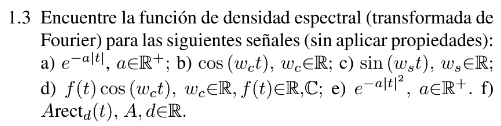

### a) $x(t) = e^{-a|t|}$, con $a \in \mathbb{R}^+$

1.  **Separar la integral:** Debido al valor absoluto $|t|$, debemos dividir la integral en dos partes: una para $t < 0$ (donde $|t| = -t$) y otra para $t > 0$ (donde $|t| = t$).
  $X(j\omega) = \int_{-\infty}^{0} e^{-a(-t)} e^{-j\omega t} dt + \int_{0}^{\infty} e^{-at} e^{-j\omega t} dt$

2.  **Agrupar exponentes:**
  $X(j\omega) = \int_{-\infty}^{0} e^{at} e^{-j\omega t} dt + \int_{0}^{\infty} e^{-at} e^{-j\omega t} dt$
  $X(j\omega) = \int_{-\infty}^{0} e^{(a - j\omega)t} dt + \int_{0}^{\infty} e^{-(a + j\omega)t} dt$

3.  **Resolver las integrales:**
  $X(j\omega) = \left[ \frac{1}{a - j\omega} e^{(a - j\omega)t} \right]_{-\infty}^{0} + \left[ \frac{1}{-(a + j\omega)} e^{-(a + j\omega)t} \right]_{0}^{\infty}$

4.  **Evaluar los límites:**
    * Para el primer término:
        $\left( \frac{1}{a - j\omega} e^{0} \right) - \left( \lim_{t \to -\infty} \frac{1}{a - j\omega} e^{at} e^{-j\omega t} \right)$
        Como $a > 0$, $e^{at} \to 0$ cuando $t \to -\infty$. Así que el límite es 0.
        El primer término es: $\frac{1}{a - j\omega}$
    * Para el segundo término:
        $\left( \lim_{t \to \infty} \frac{-1}{a + j\omega} e^{-at} e^{-j\omega t} \right) - \left( \frac{-1}{a + j\omega} e^{0} \right)$
        Como $a > 0$, $e^{-at} \to 0$ cuando $t \to \infty$. Así que el límite es 0.
        El segundo término es: $0 - \left( \frac{-1}{a + j\omega} \right) = \frac{1}{a + j\omega}$

5.  **Sumar los resultados:**
    $X(j\omega) = \frac{1}{a - j\omega} + \frac{1}{a + j\omega}$
    $X(j\omega) = \frac{(a + j\omega) + (a - j\omega)}{(a - j\omega)(a + j\omega)}$
    $X(j\omega) = \frac{2a}{a^2 - (j\omega)^2} = \frac{2a}{a^2 - (-1)\omega^2}$

    **Resultado:**
    $$X(j\omega) = \frac{2a}{a^2 + \omega^2}$$


### b) $x(t) = \cos(\omega_c t)$

Para esta señal (y la del seno), no podemos usar la propiedad de modulación. Debemos usar la **identidad de Euler** y la definición integral de la **Delta de Dirac**.

* Identidad de Euler: $\cos(\omega_c t) = \frac{e^{j\omega_c t} + e^{-j\omega_c t}}{2}$
* Transformada de una exponencial compleja (que se deriva de la integral de la delta):
    $\mathcal{F}\{e^{j\omega_0 t}\} = \int_{-\infty}^{\infty} e^{j\omega_0 t} e^{-j\omega t} dt = \int_{-\infty}^{\infty} e^{-j(\omega - \omega_0)t} dt = 2\pi\delta(\omega - \omega_0)$

1.  **Aplicar la definición de la FT:**
    $X(j\omega) = \int_{-\infty}^{\infty} \left( \frac{e^{j\omega_c t} + e^{-j\omega_c t}}{2} \right) e^{-j\omega t} dt$

2.  **Separar la integral:**
    $X(j\omega) = \frac{1}{2} \int_{-\infty}^{\infty} e^{j\omega_c t} e^{-j\omega t} dt + \frac{1}{2} \int_{-\infty}^{\infty} e^{-j\omega_c t} e^{-j\omega t} dt$

3.  **Usar la identidad de la delta:**
    * La primera integral es $\mathcal{F}\{e^{j\omega_c t}\} = 2\pi\delta(\omega - \omega_c)$
    * La segunda integral es $\mathcal{F}\{e^{-j\omega_c t}\} = \mathcal{F}\{e^{j(-\omega_c) t}\} = 2\pi\delta(\omega - (-\omega_c)) = 2\pi\delta(\omega + \omega_c)$

4.  **Combinar los resultados:**
    $X(j\omega) = \frac{1}{2} [ 2\pi\delta(\omega - \omega_c) + 2\pi\delta(\omega + \omega_c) ]$

    **Resultado:**
    $$X(j\omega) = \pi (\delta(\omega - \omega_c) + \delta(\omega + \omega_c))$$


### c) $x(t) = \sin(\omega_s t)$

El proceso es idéntico al del coseno, pero usando la identidad de Euler para el seno:
$\sin(\omega_s t) = \frac{e^{j\omega_s t} - e^{-j\omega_s t}}{2j}$

1.  **Aplicar la definición de la FT:**
    $X(j\omega) = \int_{-\infty}^{\infty} \left( \frac{e^{j\omega_s t} - e^{-j\omega_s t}}{2j} \right) e^{-j\omega t} dt$

2.  **Separar la integral:**
    $X(j\omega) = \frac{1}{2j} \int_{-\infty}^{\infty} e^{j\omega_s t} e^{-j\omega t} dt - \frac{1}{2j} \int_{-\infty}^{\infty} e^{-j\omega_s t} e^{-j\omega t} dt$

3.  **Usar la identidad de la delta:**
    $X(j\omega) = \frac{1}{2j} [ 2\pi\delta(\omega - \omega_s) - 2\pi\delta(\omega + \omega_s) ]$

4.  **Simplificar:**
    $X(j\omega) = \frac{\pi}{j} [ \delta(\omega - \omega_s) - \delta(\omega + \omega_s) ]$

    (Opcionalmente, $1/j = -j$)
    $X(j\omega) = -j\pi (\delta(\omega - \omega_s) - \delta(\omega + \omega_s)) = j\pi (\delta(\omega + \omega_s) - \delta(\omega - \omega_s))$

    **Resultado (forma estándar):**
    $$X(j\omega) = \frac{\pi}{j} (\delta(\omega - \omega_s) - \delta(\omega + \omega_s))$$


### d) $x(t) = f(t) \cos(\omega_c t)$

Este ejercicio pide, en esencia, **derivar la propiedad de modulación** usando la definición integral. Asumimos que $F(j\omega) = \mathcal{F}\{f(t)\}$.

1.  **Usar la identidad de Euler para el coseno:**
    $x(t) = f(t) \left( \frac{e^{j\omega_c t} + e^{-j\omega_c t}}{2} \right)$

2.  **Aplicar la definición de la FT:**
    $X(j\omega) = \int_{-\infty}^{\infty} \left[ f(t) \left( \frac{e^{j\omega_c t} + e^{-j\omega_c t}}{2} \right) \right] e^{-j\omega t} dt$

3.  **Separar la integral:**
    $X(j\omega) = \frac{1}{2} \int_{-\infty}^{\infty} f(t) e^{j\omega_c t} e^{-j\omega t} dt + \frac{1}{2} \int_{-\infty}^{\infty} f(t) e^{-j\omega_c t} e^{-j\omega t} dt$

4.  **Agrupar exponentes:**
    $X(j\omega) = \frac{1}{2} \int_{-\infty}^{\infty} f(t) e^{-j(\omega - \omega_c)t} dt + \frac{1}{2} \int_{-\infty}^{\infty} f(t) e^{-j(\omega + \omega_c)t} dt$

5.  **Reconocer la definición de $F(j\omega)$:**
    Recordemos que $F(j\omega) = \int_{-\infty}^{\infty} f(t) e^{-j\omega t} dt$.
    * La primera integral es $F(j\omega)$ evaluada en $(\omega - \omega_c)$, es decir, $F(j(\omega - \omega_c))$.
    * La segunda integral es $F(j\omega)$ evaluada en $(\omega + \omega_c)$, es decir, $F(j(\omega + \omega_c))$.

    **Resultado:**
    $$X(j\omega) = \frac{1}{2} [ F(j(\omega - \omega_c)) + F(j(\omega + \omega_c)) ]$$


### e) $x(t) = e^{-a|t|^2} = e^{-at^2}$, con $a \in \mathbb{R}^+$

Esta es la transformada de una **función Gaussiana**. Se resuelve usando el truco de "completar el cuadrado" en el exponente.

1.  **Aplicar la definición de la FT:**
    $X(j\omega) = \int_{-\infty}^{\infty} e^{-at^2} e^{-j\omega t} dt = \int_{-\infty}^{\infty} e^{-(at^2 + j\omega t)} dt$

2.  **Completar el cuadrado para el exponente $(at^2 + j\omega t)$:**
    $at^2 + j\omega t = a(t^2 + \frac{j\omega}{a} t)$
    Para completar $(t + b)^2 = t^2 + 2bt + b^2$, necesitamos $b = \frac{j\omega}{2a}$.
    $a \left[ \left( t + \frac{j\omega}{2a} \right)^2 - \left( \frac{j\omega}{2a} \right)^2 \right] = a \left( t + \frac{j\omega}{2a} \right)^2 - a \left( \frac{j^2\omega^2}{4a^2} \right)$
    $= a \left( t + \frac{j\omega}{2a} \right)^2 - a \left( \frac{-\omega^2}{4a^2} \right) = a \left( t + \frac{j\omega}{2a} \right)^2 + \frac{\omega^2}{4a}$

3.  **Sustituir en la integral:**
    $X(j\omega) = \int_{-\infty}^{\infty} e^{-\left[ a (t + \frac{j\omega}{2a})^2 + \frac{\omega^2}{4a} \right]} dt$
    $X(j\omega) = \int_{-\infty}^{\infty} e^{-a(t + \frac{j\omega}{2a})^2} e^{-\frac{\omega^2}{4a}} dt$

4.  **Sacar el término constante (que no depende de $t$):**
    $X(j\omega) = e^{-\frac{\omega^2}{4a}} \int_{-\infty}^{\infty} e^{-a(t + \frac{j\omega}{2a})^2} dt$

5.  **Resolver la integral Gaussiana:**
    Hacemos un cambio de variable $u = t + \frac{j\omega}{2a}$, por lo que $du = dt$.
    Se usa la identidad de la integral Gaussiana: $\int_{-\infty}^{\infty} e^{-au^2} du = \sqrt{\frac{\pi}{a}}$
    $X(j\omega) = e^{-\frac{\omega^2}{4a}} \cdot \sqrt{\frac{\pi}{a}}$

    **Resultado:**
    $$X(j\omega) = \sqrt{\frac{\pi}{a}} e^{-\frac{\omega^2}{4a}}$$
    (La transformada de una Gaussiana es otra Gaussiana).


### f) $x(t) = A \cdot \text{rect}_d(t)$ (Asumiendo que "Arct" es $A \cdot \text{rect}$)

Esta es una función de pulso rectangular. Generalmente $A \cdot \text{rect}(t/d)$, que es un pulso de amplitud $A$, centrado en 0, y con ancho $d$.
Es decir, $x(t) = A$ para $|t| \le d/2$, y $x(t) = 0$ el resto del tiempo. Los límites de la integral son de $-d/2$ a $d/2$.

1.  **Aplicar la definición de la FT:**
    $X(j\omega) = \int_{-d/2}^{d/2} A \cdot e^{-j\omega t} dt$

2.  **Resolver la integral:**
    $X(j\omega) = A \left[ \frac{1}{-j\omega} e^{-j\omega t} \right]_{-d/2}^{d/2}$

3.  **Evaluar los límites:**
    $X(j\omega) = \frac{A}{-j\omega} \left[ e^{-j\omega (d/2)} - e^{-j\omega (-d/2)} \right]$
    $X(j\omega) = \frac{A}{-j\omega} \left[ e^{-j\omega d/2} - e^{j\omega d/2} \right]$

4.  **Simplificar:**
    Multiplicamos el $(-1)$ del denominador por el término entre corchetes:
    $X(j\omega) = \frac{A}{j\omega} \left[ e^{j\omega d/2} - e^{-j\omega d/2} \right]$
    Usamos la identidad de Euler: $e^{jx} - e^{-jx} = 2j \sin(x)$.
    Aquí, $x = \omega d/2$.
    $X(j\omega) = \frac{A}{j\omega} \left[ 2j \sin(\omega d/2) \right]$

5.  **Cancelar $j$:**
    $X(j\omega) = \frac{2A}{\omega} \sin(\omega d/2)$

    Esta es una respuesta válida, pero se suele expresar usando la función $\text{sinc}(x) = \sin(x)/x$. Para ello, multiplicamos y dividimos por $d/2$:
    $X(j\omega) = A \cdot d \cdot \frac{2}{\omega d} \sin(\omega d/2) = A \cdot d \cdot \frac{\sin(\omega d/2)}{\omega d/2}$

    **Resultado (en forma de Sinc):**
    $$X(j\omega) = A d \cdot \text{sinc}\left(\frac{\omega d}{2}\right)$$
    (Usando la definición no normalizada $\text{sinc}(x) = \sin(x)/x$)

## Punto 1.4

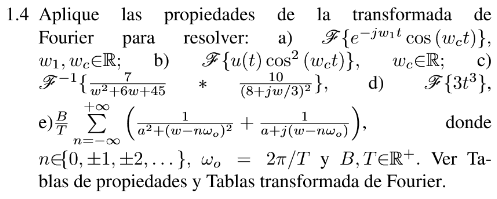

**Pares y Propiedades Clave Utilizadas:**
* **Par - Delta:** $\mathcal{F}\{1\} = 2\pi\delta(\omega)$
* **Par - Coseno:** $\mathcal{F}\{\cos(\omega_c t)\} = \pi[\delta(\omega - \omega_c) + \delta(\omega + \omega_c)]$
* **Par - Exponencial (un lado):** $\mathcal{F}\{e^{-at}u(t)\} = \frac{1}{a+j\omega}$
* **Par - Exponencial (dos lados):** $\mathcal{F}\{e^{-a|t|}\} = \frac{2a}{a^2 + \omega^2}$
* **Par - Rampa Exponencial:** $\mathcal{F}\{t e^{-at}u(t)\} = \frac{1}{(a+j\omega)^2}$
* **Par - Escalón (Step):** $\mathcal{F}\{u(t)\} = \pi\delta(\omega) + \frac{1}{j\omega}$
* **Propiedad - Linealidad:** $\mathcal{F}\{ax_1(t) + bx_2(t)\} = aX_1(\omega) + bX_2(\omega)$
* **Propiedad - Desplazamiento en Frecuencia (Modulación):** $\mathcal{F}\{e^{j\omega_0 t} x(t)\} = X(\omega - \omega_0)$
* **Propiedad - Modulación (Coseno):** $\mathcal{F}\{x(t)\cos(\omega_0 t)\} = \frac{1}{2}[X(\omega - \omega_0) + X(\omega + \omega_0)]$
* **Propiedad - Convolución en Frecuencia:** $\mathcal{F}\{x_1(t) \cdot x_2(t)\} = \frac{1}{2\pi} [X_1(\omega) * X_2(\omega)]$
* **Propiedad - Convolución en Tiempo:** $\mathcal{F}\{x_1(t) * x_2(t)\} = X_1(\omega) \cdot X_2(\omega)$
* **Propiedad - Derivada en Frecuencia:** $\mathcal{F}\{t^n x(t)\} = (j)^n \frac{d^n}{d\omega^n} X(\omega)$
* **Propiedad - Muestreo (Tren de Impulsos):** $\mathcal{F}\{\sum_{n=-\infty}^{\infty} x(t) \delta(t-nT)\} = \frac{1}{T} \sum_{n=-\infty}^{\infty} X(\omega - n\omega_0)$, donde $\omega_0 = 2\pi/T$.

---

####
### a) $\mathcal{F}\{e^{-jw_1 t} \cos(w_c t)\}$

Usamos la propiedad de **Desplazamiento en Frecuencia (Modulación)**:
$\mathcal{F}\{e^{j\omega_0 t} x(t)\} = X(\omega - \omega_0)$

1.  Primero, identificamos $x(t)$ y el par base:
  $x(t) = \cos(w_c t)$
  $X(\omega) = \mathcal{F}\{\cos(w_c t)\} = \pi[\delta(\omega - w_c) + \delta(\omega + w_c)]$

2.  Identificamos el desplazamiento $\omega_0$. En este caso, $\omega_0 = -w_1$.

3.  Aplicamos la propiedad, sustituyendo $\omega$ por $(\omega - \omega_0) = (\omega - (-w_1)) = (\omega + w_1)$ en $X(\omega)$:
  $$\mathcal{F}\{e^{-jw_1 t} \cos(w_c t)\} = X(\omega + w_1)$$
  $$= \pi[\delta((\omega + w_1) - w_c) + \delta((\omega + w_1) + w_c)]$$

**Resultado:**
$$\mathcal{F}\{e^{-jw_1 t} \cos(w_c t)\} = \pi[\delta(\omega + w_1 - w_c) + \delta(\omega + w_1 + w_c)]$$

---

### b) $\mathcal{F}\{u(t) \cos^2(w_c t)\}$

1.  Primero, usamos la **identidad trigonométrica**: $\cos^2(\theta) = \frac{1}{2} + \frac{1}{2}\cos(2\theta)$
  $$\mathcal{F}\{u(t) [\frac{1}{2} + \frac{1}{2}\cos(2w_c t)]\}$$

2.  Aplicamos la **Linealidad**:
    $$\frac{1}{2}\mathcal{F}\{u(t)\} + \frac{1}{2}\mathcal{F}\{u(t)\cos(2w_c t)\}$$

3.  Calculamos cada término:
    * **Término 1 (Par base):**
        $\mathcal{F}\{u(t)\} = \pi\delta(\omega) + \frac{1}{j\omega}$
    * **Término 2 (Propiedad Modulación Coseno):**
        Usamos $x(t) = u(t)$ y $\omega_0 = 2w_c$.
        $\mathcal{F}\{u(t)\cos(2w_c t)\} = \frac{1}{2}[X(\omega - 2w_c) + X(\omega + 2w_c)]$
        $= \frac{1}{2} \left[ (\pi\delta(\omega - 2w_c) + \frac{1}{j(\omega - 2w_c)}) + (\pi\delta(\omega + 2w_c) + \frac{1}{j(\omega + 2w_c)}) \right]$

4.  Combinamos todo:
    $$\frac{1}{2} \left[ \pi\delta(\omega) + \frac{1}{j\omega} \right] + \frac{1}{2} \left[ \frac{1}{2} (\pi\delta(\omega - 2w_c) + \frac{1}{j(\omega - 2w_c)} + \pi\delta(\omega + 2w_c) + \frac{1}{j(\omega + 2w_c)}) \right]$$

**Resultado:**
$$\frac{\pi}{2}\delta(\omega) + \frac{1}{2j\omega} + \frac{\pi}{4}[\delta(\omega - 2w_c) + \delta(\omega + 2w_c)] + \frac{1}{4j} \left[ \frac{1}{\omega - 2w_c} + \frac{1}{\omega + 2w_c} \right]$$

---

### c) $\mathcal{F}^{-1}\left\{ \frac{7}{w^2+6w+45} * \frac{10}{(8+jw/3)^2} \right\}$

Usamos la propiedad de **Convolución en Frecuencia**:
$\mathcal{F}^{-1}\{X_1(\omega) * X_2(\omega)\} = 2\pi \cdot x_1(t) \cdot x_2(t)$

1.  **Encontrar $x_1(t)$:**
    $X_1(\omega) = \frac{7}{w^2+6w+45}$
    Completamos el cuadrado: $w^2+6w+45 = (w^2+6w+9) + 36 = (w+3)^2 + 6^2$
    $X_1(\omega) = \frac{7}{(w+3)^2 + 6^2}$
    * Usamos el par: $\mathcal{F}\{e^{-a|t|}\} = \frac{2a}{a^2 + \omega^2}$. Para $a=6$, $\mathcal{F}\{e^{-6|t|}\} = \frac{12}{36 + \omega^2}$.
    * Entonces, $\mathcal{F}^{-1}\{\frac{1}{\omega^2 + 6^2}\} = \frac{1}{12}e^{-6|t|}$.
    * Usamos Desplazamiento en Frecuencia: $X_1(\omega) = 7 \cdot Y(\omega+3)$, donde $Y(\omega) = \frac{1}{\omega^2+6^2}$.
    * $x_1(t) = \mathcal{F}^{-1}\{7 Y(\omega+3)\} = 7 \cdot e^{-j3t} \cdot y(t) = \frac{7}{12} e^{-j3t} e^{-6|t|}$

2.  **Encontrar $x_2(t)$:**
    $X_2(\omega) = \frac{10}{(8+jw/3)^2}$
    * Usamos el par: $\mathcal{F}\{t e^{-at}u(t)\} = \frac{1}{(a+j\omega)^2}$.
    * Sea $Y(\omega) = \frac{1}{(8+j\omega)^2}$, entonces $y(t) = t e^{-8t}u(t)$.
    * $X_2(\omega) = 10 \cdot Y(\omega/3)$.
    * Usamos la propiedad de **Escalamiento en Tiempo**: $\mathcal{F}\{y(at)\} = \frac{1}{|a|}Y(\frac{\omega}{a})$.
    * Con $a=1/3$: $\mathcal{F}\{y(t/3)\} = 3 Y(3\omega)$. No nos sirve.
    * Con $a=3$: $\mathcal{F}\{y(3t)\} = \frac{1}{3}Y(\frac{\omega}{3})$. ¡Sí!
    * Entonces, $\mathcal{F}^{-1}\{Y(\omega/3)\} = 3y(3t) = 3 \cdot (3t)e^{-8(3t)}u(3t) = 9t e^{-24t}u(t)$ (ya que $u(3t)=u(t)$).
    * $x_2(t) = \mathcal{F}^{-1}\{10 \cdot Y(\omega/3)\} = 10 \cdot (9t e^{-24t}u(t)) = 90t e^{-24t}u(t)$

3.  **Combinar:**
    $2\pi \cdot x_1(t) \cdot x_2(t) = 2\pi \cdot \left( \frac{7}{12} e^{-j3t} e^{-6|t|} \right) \cdot \left( 90t e^{-24t}u(t) \right)$
    * Debido a $u(t)$, la expresión solo es válida para $t > 0$, donde $|t| = t$.
    $= 2\pi \cdot \frac{7 \cdot 90}{12} \cdot t \cdot e^{-j3t} \cdot e^{-6t} \cdot e^{-24t} u(t)$
    $= 2\pi \cdot (\frac{630}{12}) \cdot t \cdot e^{-30t} e^{-j3t} u(t)$
    $= 2\pi \cdot (52.5) \cdot t \cdot e^{-(30+3j)t} u(t)$

**Resultado:**
$$\mathcal{F}^{-1}\left\{ \dots \right\} = 105\pi \cdot t \cdot e^{-(30+3j)t} u(t)$$

---

### d) $\mathcal{F}\{3t^3\}$

Usamos la propiedad de **Derivada en Frecuencia**:
$\mathcal{F}\{t^n x(t)\} = (j)^n \frac{d^n}{d\omega^n} X(\omega)$

1.  Identificamos $n=3$, $x(t) = 3$.
2.  Buscamos $X(\omega)$:
    $X(\omega) = \mathcal{F}\{3\} = 3 \cdot \mathcal{F}\{1\} = 3 \cdot (2\pi\delta(\omega)) = 6\pi\delta(\omega)$
3.  Aplicamos la propiedad:
    $$\mathcal{F}\{3t^3\} = (j)^3 \frac{d^3}{d\omega^3} [6\pi\delta(\omega)]$$
    $$= -j \cdot 6\pi \frac{d^3}{d\omega^3} \delta(\omega)$$

**Resultado:**
$$\mathcal{F}\{3t^3\} = -j6\pi \delta'''(\omega)$$
(Donde $\delta'''(\omega)$ es la tercera derivada de la función delta, o "triplete").

---

### e) $\frac{B}{T} \sum_{n=-\infty}^{+\infty} \left( \frac{1}{a^2+(w-n\omega_o)^2} + \frac{1}{a+j(w-n\omega_o)} \right)$

Este problema pide "resolver", lo que implica identificar la expresión en el dominio del tiempo $z(t)$ cuya transformada es esta expresión.

1.  La expresión tiene la forma de la **Propiedad de Muestreo**:
    $Z(\omega) = \frac{B}{T} \sum_{n=-\infty}^{+\infty} Y(\omega - n\omega_0)$
    La transformada inversa de esto es:
    $z(t) = B \cdot y(t) \cdot \sum_{n=-\infty}^{\infty} \delta(t-nT)$
    (Asumiendo $\omega_0 = 2\pi/T$)

2.  Necesitamos encontrar $y(t)$ a partir de $Y(\omega)$:
  $$Y(\omega) = \frac{1}{a^2+\omega^2} + \frac{1}{a+j\omega}$$

3.  Aplicamos la **Linealidad** a la $\mathcal{F}^{-1}$:
  $$y(t) = \mathcal{F}^{-1}\left\{\frac{1}{a^2+\omega^2}\right\} + \mathcal{F}^{-1}\left\{\frac{1}{a+j\omega}\right\}$$
    * **Término 1 (Par Exponencial doble):**
  $\mathcal{F}\{e^{-a|t|}\} = \frac{2a}{a^2 + \omega^2} \implies \mathcal{F}^{-1}\left\{\frac{1}{a^2+\omega^2}\right\} = \frac{1}{2a}e^{-a|t|}$
    * **Término 2 (Par Exponencial simple):**
  $\mathcal{F}\{e^{-at}u(t)\} = \frac{1}{a+j\omega} \implies \mathcal{F}^{-1}\left\{\frac{1}{a+j\omega}\right\} = e^{-at}u(t)$

4.  Juntamos $y(t)$:
  $$y(t) = \frac{1}{2a}e^{-a|t|} + e^{-at}u(t)$$

5.  Sustituimos $y(t)$ en la expresión del paso 1:
  $$z(t) = B \cdot \left[ \frac{1}{2a}e^{-a|t|} + e^{-at}u(t) \right] \cdot \sum_{n=-\infty}^{\infty} \delta(t-nT)$$

**Resultado:**
La expresión en el dominio de la frecuencia es la Transformada de Fourier de la siguiente señal en el dominio del tiempo:
$$z(t) = B \left( \frac{1}{2a}e^{-a|t|} + e^{-at}u(t) \right) \sum_{n=-\infty}^{\infty} \delta(t-nT)$$

## Punto 1.5

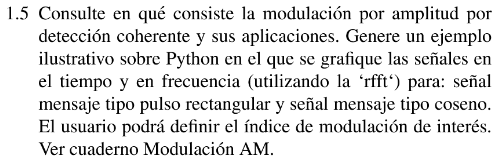

### Modulación de Amplitud con Detección Coherente

La **modulación de amplitud (AM)** es una técnica para transmitir información, como una señal de audio, a través de una onda portadora de mayor frecuencia. En la **detección coherente**, también conocida como detección síncrona, el receptor utiliza una réplica exacta de la onda portadora original, tanto en frecuencia como en fase, para demodular la señal y recuperar la información original.

El proceso funciona multiplicando la señal AM recibida por la portadora local generada en el receptor. Después de esta multiplicación, se aplica un filtro pasabajos para eliminar las componentes de alta frecuencia, dejando únicamente la señal de mensaje original recuperada.

La principal ventaja de la detección coherente es su **robustez frente al ruido y la interferencia**. Al estar sincronizado con la portadora original, el receptor puede discriminar de manera muy efectiva la señal deseada de otras señales no deseadas. Sin embargo, su principal desventaja es la **complejidad y el costo** de tener que generar una portadora local perfectamente sincronizada en el receptor.

La ecuación matemática de una señal AM de doble banda lateral con portadora (DSB-FC) es:

$$s(t) = A_c [1 + k_a m(t)] \cos(2\pi f_c t)$$

Donde:
* $A_c$ es la amplitud de la portadora.
* $m(t)$ es la señal mensaje.
* $f_c$ es la frecuencia de la portadora.
* $k_a$ es la sensibilidad de amplitud del modulador.
* El **índice de modulación** ($m$) es $m = k_a \cdot A_m$, donde $A_m$ es la amplitud máxima de la señal mensaje.

---

### Aplicaciones Principales

Debido a su complejidad, la detección coherente se reserva para aplicaciones donde la alta fidelidad y la resistencia al ruido son críticas:

* **Radiodifusión AM Estéreo:** En el sistema C-QUAM (Compatible Quadrature Amplitude Modulation), se utiliza para separar las señales de audio izquierda y derecha.
* **Comunicaciones de Datos:** En algunos módems de baja velocidad y sistemas de transmisión de datos donde la integridad de la señal es primordial.
* **Sistemas de Radar y Telemetría:** Se emplea en sistemas que necesitan extraer información precisa de señales débiles y ruidosas.

Introduce el índice de modulación (ej. 0.5, 1.0, 1.5): 0.5


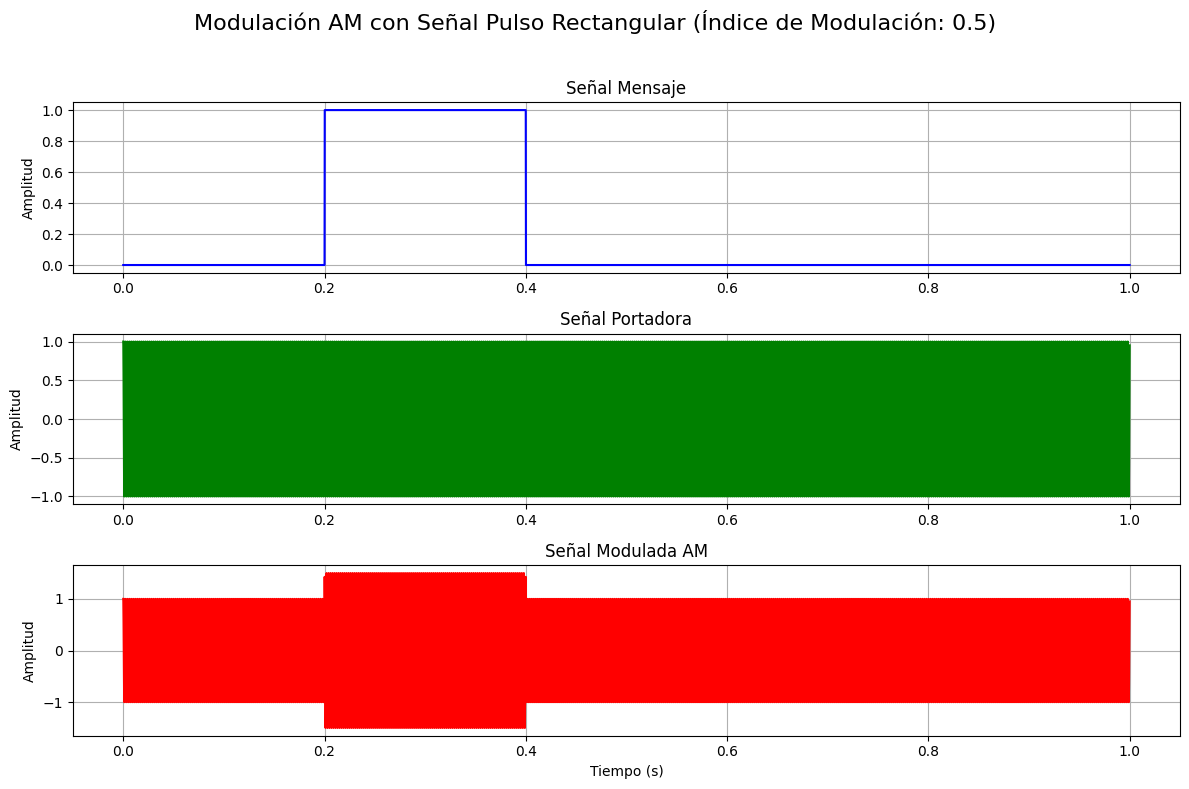

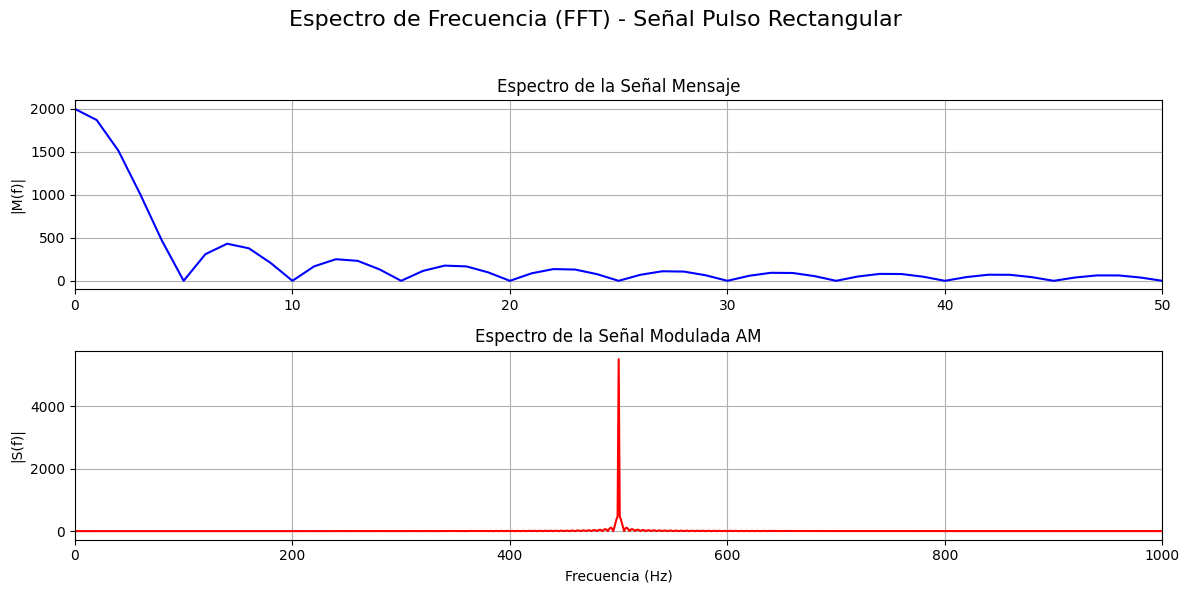

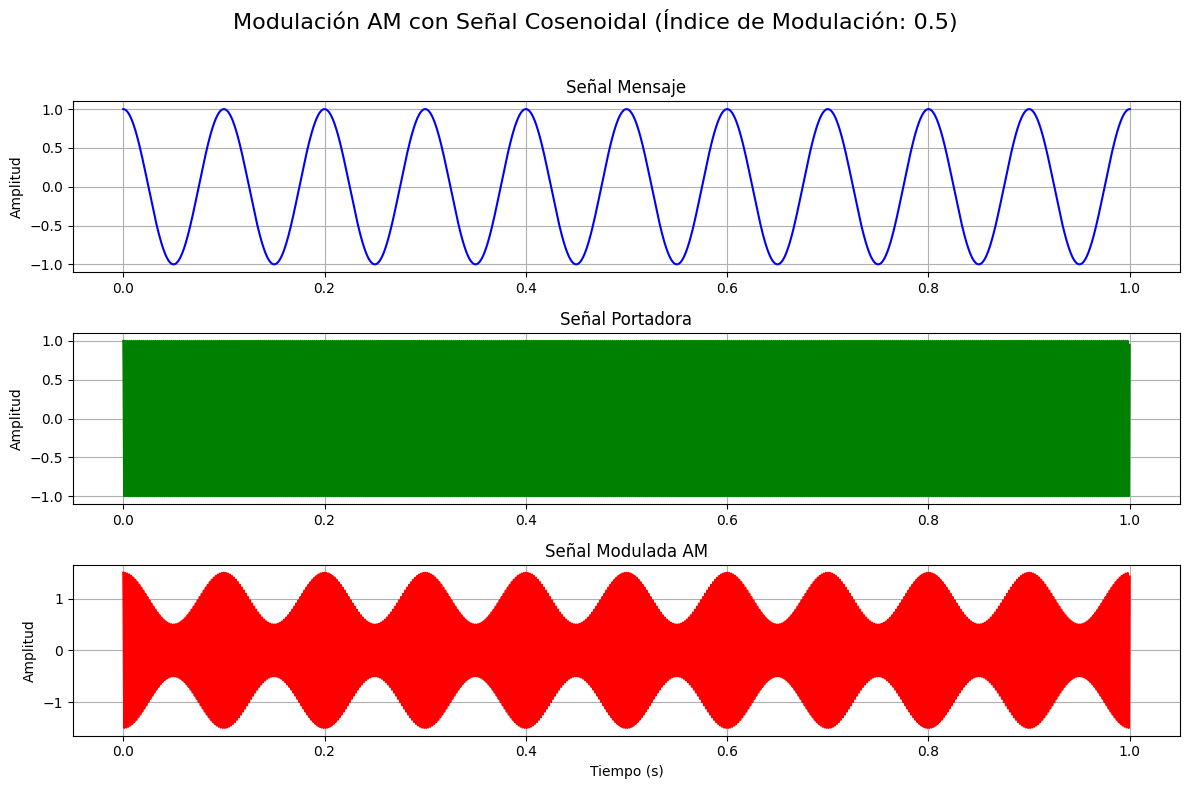

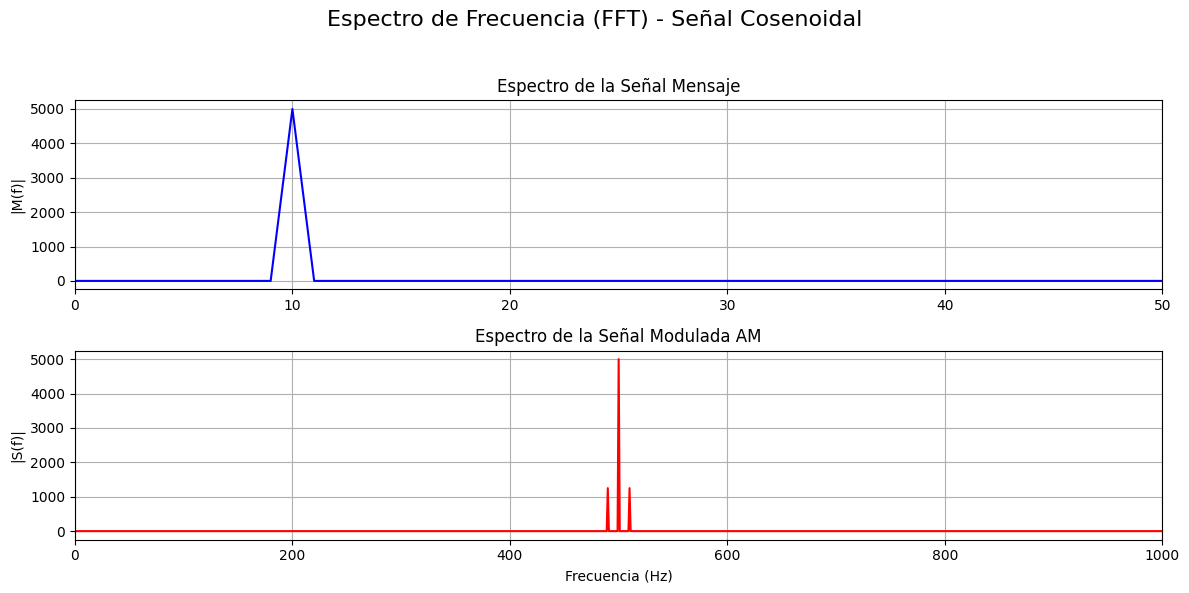

In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# IMPORTS - Librerías necesarias para procesamiento de señales y gráficas
# ═══════════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq

# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN DE SEÑALES - Genera gráficas en tiempo y frecuencia
# ═══════════════════════════════════════════════════════════════════════════
def plot_signals(t, msg, carrier, am_signal, modulation_index, msg_type):
    """
    Función para graficar las señales en tiempo y frecuencia.
    """
    # ────────────────────────────────────────────────────────────────────────
    # DOMINIO DEL TIEMPO - Visualiza las señales en función del tiempo
    # ────────────────────────────────────────────────────────────────────────
    plt.figure(figsize=(12, 8))
    plt.suptitle(f'Modulación AM con Señal {msg_type} (Índice de Modulación: {modulation_index})', fontsize=16)

    plt.subplot(3, 1, 1)
    plt.title('Señal Mensaje')
    plt.plot(t, msg, 'b')
    plt.ylabel('Amplitud')
    plt.grid(True)

    plt.subplot(3, 1, 2)
    plt.title('Señal Portadora')
    plt.plot(t, carrier, 'g')
    plt.ylabel('Amplitud')
    plt.grid(True)

    plt.subplot(3, 1, 3)
    plt.title('Señal Modulada AM')
    plt.plot(t, am_signal, 'r')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # ────────────────────────────────────────────────────────────────────────
    # DOMINIO DE LA FRECUENCIA - Analiza el espectro mediante FFT
    # ────────────────────────────────────────────────────────────────────────
    N = len(t)
    T = t[1] - t[0]

    yf_msg = rfft(msg)
    xf_msg = rfftfreq(N, T)

    yf_am = rfft(am_signal)
    xf_am = rfftfreq(N, T)

    plt.figure(figsize=(12, 6))
    plt.suptitle(f'Espectro de Frecuencia (FFT) - Señal {msg_type}', fontsize=16)

    plt.subplot(2, 1, 1)
    plt.title('Espectro de la Señal Mensaje')
    plt.plot(xf_msg, np.abs(yf_msg), 'b')
    plt.ylabel('|M(f)|')
    plt.xlim(0, fc * 0.1) # Zoom en las frecuencias bajas para la señal mensaje
    plt.grid(True)

    plt.subplot(2, 1, 2)
    plt.title('Espectro de la Señal Modulada AM')
    plt.plot(xf_am, np.abs(yf_am), 'r')
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('|S(f)|')
    plt.xlim(0, fc * 2) # Visualizar hasta el doble de la frecuencia portadora
    plt.grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# ═══════════════════════════════════════════════════════════════════════════
# PARÁMETROS GENERALES - Configuración del sistema de muestreo y señales
# ═══════════════════════════════════════════════════════════════════════════
sampling_rate = 10000  # Tasa de muestreo (Hz)
t = np.arange(0, 1.0, 1/sampling_rate) # Vector de tiempo de 1 segundo

# ────────────────────────────────────────────────────────────────────────
# FRECUENCIAS - Define las frecuencias de portadora y señal mensaje
# ────────────────────────────────────────────────────────────────────────
fc = 500  # Frecuencia de la portadora (Hz)
fm = 10   # Frecuencia de la señal mensaje (para coseno)

# ────────────────────────────────────────────────────────────────────────
# AMPLITUDES - Define las amplitudes de portadora y señal mensaje
# ────────────────────────────────────────────────────────────────────────
Ac = 1.0  # Amplitud de la portadora
Am = 1.0  # Amplitud de la señal mensaje

# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN DE MODULACIÓN - Parámetros del índice de modulación AM
# ═══════════════════════════════════════════════════════════════════════════
# m < 1: Submodulación
# m = 1: Modulación crítica
# m > 1: Sobremodulación
modulation_index = float(input("Introduce el índice de modulación (ej. 0.5, 1.0, 1.5): "))

# Sensibilidad del modulador (ka) se ajusta para obtener el índice deseado
ka = modulation_index / Am

# ────────────────────────────────────────────────────────────────────────
# GENERACIÓN DE PORTADORA - Crea la señal portadora sinusoidal
# ────────────────────────────────────────────────────────────────────────
carrier = Ac * np.cos(2 * np.pi * fc * t)

# ═══════════════════════════════════════════════════════════════════════════
# EJEMPLO 1: SEÑAL MENSAJE TIPO PULSO RECTANGULAR
# ═══════════════════════════════════════════════════════════════════════════
msg_pulse = np.zeros_like(t)
# Crear un pulso rectangular entre t=0.2s y t=0.4s
msg_pulse[(t > 0.2) & (t < 0.4)] = Am
am_signal_pulse = Ac * (1 + ka * msg_pulse) * np.cos(2 * np.pi * fc * t)

plot_signals(t, msg_pulse, carrier, am_signal_pulse, modulation_index, "Pulso Rectangular")

# ═══════════════════════════════════════════════════════════════════════════
# EJEMPLO 2: SEÑAL MENSAJE TIPO COSENO
# ═══════════════════════════════════════════════════════════════════════════
msg_cosine = Am * np.cos(2 * np.pi * fm * t)
am_signal_cosine = Ac * (1 + ka * msg_cosine) * np.cos(2 * np.pi * fc * t)

plot_signals(t, msg_cosine, carrier, am_signal_cosine, modulation_index, "Cosenoidal")

## La implementación del último ejercicio del **Punto 1.1**, junto con el **Punto 1.6** y **Punto 1.7** estan en:

[Taller2SyS_Dashboard](https://github.com/sgaleanoca/Senales_y_Sistemas/blob/segundo-corte/Taller2SyS_Dashboard.ipynb)

## Punto 2.1

### La implementación de este punto se encuentra en:

[Convolución](https://github.com/sgaleanoca/Senales_y_Sistemas/blob/segundo-corte/Punto_2-1_Convoluci%C3%B3n.ipynb)

## Punto 2.2

### La implementación de este punto se encuentra en:

[Respuesta al Impulso](https://github.com/sgaleanoca/Senales_y_Sistemas/blob/segundo-corte/Punto_2-2_Respuesta_Impulso.ipynb)

## Punto 2.3

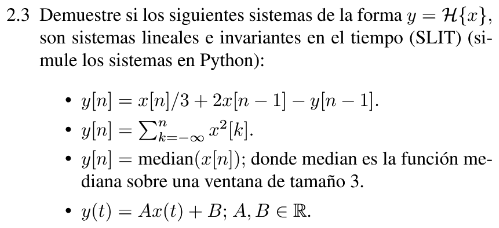

### Análisis de Sistemas Lineales e Invariantes en el Tiempo (SLIT)

A continuación, se demuestra si cada sistema es lineal e invariante en el tiempo, y se proporciona una simulación en Python.

---

### Sistema 1: $y[n] = x[n]/3 + 2x[n-1] - y[n-1]$

Esta es una ecuación de diferencias recursiva. Podemos reescribirla como:
$$y[n] + y[n-1] = \frac{1}{3}x[n] + 2x[n-1]$$

### Análisis de Linealidad

Un sistema $H$ es lineal si cumple el principio de superposición: $H\{a x_1[n] + b x_2[n]\} = a H\{x_1[n]\} + b H\{x_2[n]\}$.

1.  **Respuesta a $x_1[n]$**:
    $y_1[n] + y_1[n-1] = \frac{1}{3}x_1[n] + 2x_1[n-1]$

2.  **Respuesta a $x_2[n]$**:
    $y_2[n] + y_2[n-1] = \frac{1}{3}x_2[n] + 2x_2[n-1]$

3.  **Respuesta escalada y sumada ($a y_1 + b y_2$)**:
    $a(y_1[n] + y_1[n-1]) + b(y_2[n] + y_2[n-1]) = a(\frac{1}{3}x_1[n] + 2x_1[n-1]) + b(\frac{1}{3}x_2[n] + 2x_2[n-1])$
    $(a y_1[n] + b y_2[n]) + (a y_1[n-1] + b y_2[n-1]) = \frac{1}{3}(a x_1[n] + b x_2[n]) + 2(a x_1[n-1] + b x_2[n-1])$

4.  **Respuesta a la entrada escalada y sumada ($x_3[n] = a x_1[n] + b x_2[n]$)**:
    Sea $y_3[n]$ la salida para $x_3[n]$.
    $y_3[n] + y_3[n-1] = \frac{1}{3}x_3[n] + 2x_3[n-1]$
    $y_3[n] + y_3[n-1] = \frac{1}{3}(a x_1[n] + b x_2[n]) + 2(a x_1[n-1] + b x_2[n-1])$

Dado que la Ecuación 3 y la Ecuación 4 son idénticas (donde $y_3[n] = a y_1[n] + b y_2[n]$), el sistema cumple con el principio de superposición.

**Conclusión: El sistema ES lineal.**

### Análisis de Invarianza en el Tiempo

Un sistema es invariante en el tiempo si una entrada desplazada $x[n-n_0]$ produce una salida desplazada $y[n-n_0]$.

1.  **Salida Original**:
    $y[n] = \frac{1}{3}x[n] + 2x[n-1] - y[n-1]$

2.  **Salida Desplazada ($y_s[n] = y[n-n_0]$)**:
    Reemplazamos $n$ por $n-n_0$ en la ecuación original:
    $y[n-n_0] = \frac{1}{3}x[n-n_0] + 2x[n-n_0-1] - y[n-n_0-1]$

3.  **Salida de la Entrada Desplazada ($x_d[n] = x[n-n_0]$)**:
    Sea $y_d[n]$ la salida para la entrada $x_d[n]$.
    $y_d[n] = \frac{1}{3}x_d[n] + 2x_d[n-1] - y_d[n-1]$
    Sustituimos $x_d[n]$:
    $y_d[n] = \frac{1}{3}x[n-n_0] + 2x[n-1-n_0] - y_d[n-1]$

Al comparar la Ecuación 2 y la 3, vemos que $y_d[n] = y[n-n_0]$ (y $y_d[n-1] = y[n-n_0-1]$). Las ecuaciones son idénticas.

**Conclusión: El sistema ES invariante en el tiempo.**

### Veredicto SLIT

**El sistema ES un sistema Lineal e Invariante en el Tiempo (SLIT).**

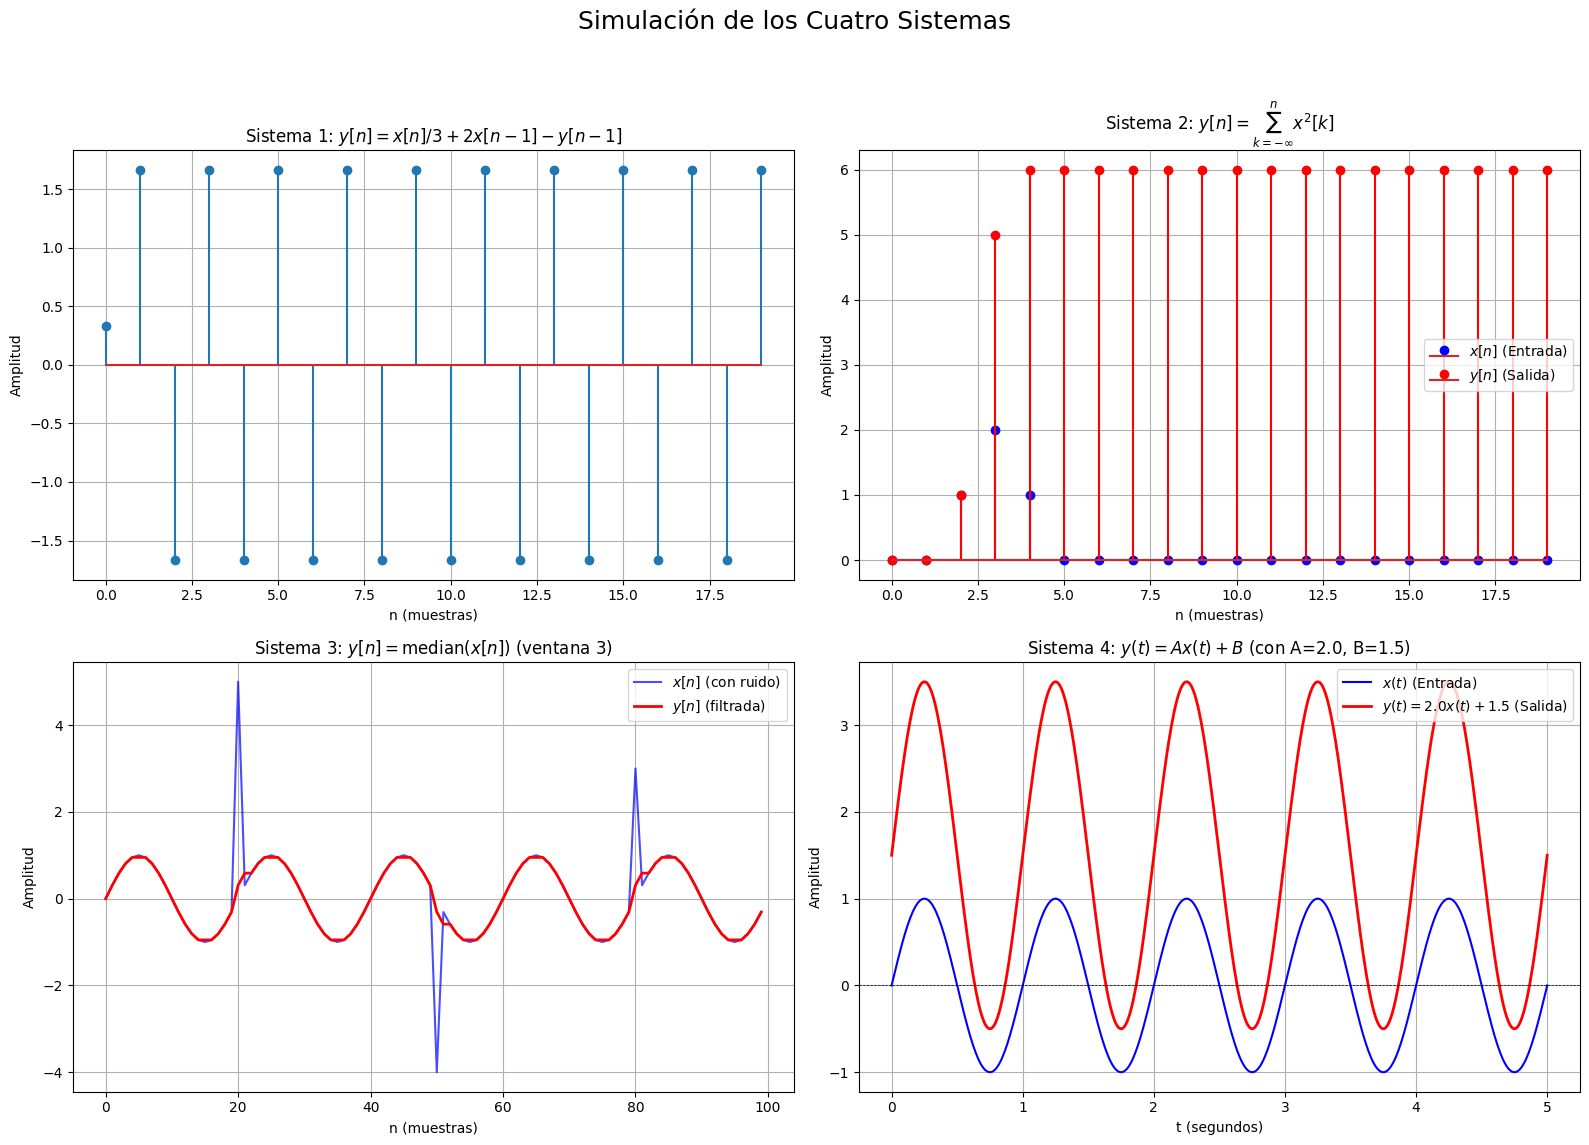

In [18]:
# ═══════════════════════════════════════════════════════════════════════════
# IMPORTS - Librerías necesarias para procesamiento de señales y gráficas
# ═══════════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, medfilt

# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN DE LA FIGURA - Crear subplots para los cuatro sistemas
# ═══════════════════════════════════════════════════════════════════════════
# Creamos una figura con 4 subplots (2 filas, 2 columnas)
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Simulación de los Cuatro Sistemas', fontsize=18)

# ═══════════════════════════════════════════════════════════════════════════
# SISTEMA 1: FILTRO IIR - y[n] = x[n]/3 + 2x[n-1] - y[n-1]
# ═══════════════════════════════════════════════════════════════════════════
# Coeficientes del filtro IIR
# y[n] + 1*y[n-1] = (1/3)*x[n] + 2*x[n-1]
b1 = [1/3, 2]  # Coeficientes de x (numerador)
a1 = [1, 1]    # Coeficientes de y (denominador)

# Señal de entrada (impulso)
n1 = np.arange(0, 20)
x1 = np.zeros_like(n1)
x1[0] = 1  # Impulso en n=0

# Simulación del filtro
y1 = lfilter(b1, a1, x1)

# Graficar
axs[0, 0].stem(n1, y1)
axs[0, 0].set_title('Sistema 1: $y[n] = x[n]/3 + 2x[n-1] - y[n-1]$', fontsize=12)
axs[0, 0].set_xlabel('n (muestras)')
axs[0, 0].set_ylabel('Amplitud')
axs[0, 0].grid(True)

# ═══════════════════════════════════════════════════════════════════════════
# SISTEMA 2: SUMA ACUMULATIVA - y[n] = Σ x^2[k]
# ═══════════════════════════════════════════════════════════════════════════
# Señal de entrada (pulso)
n2 = np.arange(0, 20)
x2 = np.zeros_like(n2, dtype=float)
x2[2:5] = [1, 2, 1]

# Simulación (suma acumulativa de la señal al cuadrado)
y2 = np.cumsum(x2**2)

# Graficar
axs[0, 1].stem(n2, x2, 'b', markerfmt='bo', label='$x[n]$ (Entrada)')
axs[0, 1].stem(n2, y2, 'r', markerfmt='ro', label='$y[n]$ (Salida)')
# Título corregido con r'' (raw string)
axs[0, 1].set_title(r'Sistema 2: $y[n] = \sum_{k=-\infty}^{n} x^2[k]$', fontsize=12)
axs[0, 1].set_xlabel('n (muestras)')
axs[0, 1].set_ylabel('Amplitud')
axs[0, 1].legend()
axs[0, 1].grid(True)

# ═══════════════════════════════════════════════════════════════════════════
# SISTEMA 3: FILTRO DE MEDIANA - y[n] = median(x[n]) (ventana 3)
# ═══════════════════════════════════════════════════════════════════════════
# Señal de entrada (senoidal con ruido impulsivo)
n3 = np.arange(0, 100)
x3 = np.sin(2 * np.pi * 0.05 * n3)
# Añadir ruido "sal y pimienta"
x3[20] = 5
x3[50] = -4
x3[80] = 3

# Simulación (filtro de mediana)
# kernel_size=3 usa una ventana de 3 puntos
y3 = medfilt(x3, kernel_size=3)

# Graficar
axs[1, 0].plot(n3, x3, 'b-', alpha=0.7, label='$x[n]$ (con ruido)')
axs[1, 0].plot(n3, y3, 'r-', linewidth=2, label='$y[n]$ (filtrada)')
# Título corregido con r'' (raw string)
axs[1, 0].set_title(r'Sistema 3: $y[n] = \mathrm{median}(x[n])$ (ventana 3)', fontsize=12)
axs[1, 0].set_xlabel('n (muestras)')
axs[1, 0].set_ylabel('Amplitud')
axs[1, 0].legend()
axs[1, 0].grid(True)

# ═══════════════════════════════════════════════════════════════════════════
# SISTEMA 4: TRANSFORMACIÓN LINEAL - y(t) = Ax(t) + B
# ═══════════════════════════════════════════════════════════════════════════
# Parámetros del sistema
A = 2.0  # Ganancia
B = 1.5  # Offset

# Señal de entrada (senoidal en tiempo continuo)
t4 = np.linspace(0, 5, 500)
x4 = np.sin(2 * np.pi * 1 * t4)

# Simulación (operación aritmética)
y4 = A * x4 + B

# Graficar
axs[1, 1].plot(t4, x4, 'b-', label='$x(t)$ (Entrada)')
axs[1, 1].plot(t4, y4, 'r-', linewidth=2, label=f'$y(t) = {A}x(t) + {B}$ (Salida)')
axs[1, 1].set_title(f'Sistema 4: $y(t) = Ax(t) + B$ (con A={A}, B={B})', fontsize=12)
axs[1, 1].set_xlabel('t (segundos)')
axs[1, 1].set_ylabel('Amplitud')
axs[1, 1].legend()
axs[1, 1].grid(True)
axs[1, 1].axhline(0, color='black', linestyle='--', linewidth=0.5) # Eje cero

# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN FINAL - Mostrar todas las gráficas
# ═══════════════════════════════════════════════════════════════════════════
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar para el título principal
plt.show()

## Punto 2.4

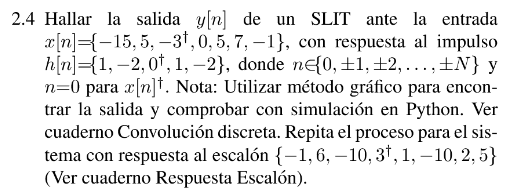

La operación fundamental que relaciona la entrada, la salida y la respuesta al impulso de un sistema SLIT es la **convolución discreta**:

$$
y[n] = x[n] * h[n] = \sum_{k=-\infty}^{\infty} x[k] h[n-k]
$$

---

#### Parte 1: Convolución con Respuesta al Impulso $h[n]$

**1. Definición de las Señales**

Primero, identificamos las señales y sus índices de tiempo. El símbolo $\dagger$ marca la muestra en $n=0$.

* **Señal de entrada $x[n]$:**
    $x[n] = \{-15, 5, -3^\dagger, 0, 5, 7, -1\}$
    Esto significa:
    * $x[-2] = -15$
    * $x[-1] = 5$
    * $x[0] = -3$
    * $x[1] = 0$
    * $x[2] = 5$
    * $x[3] = 7$
    * $x[4] = -1$

* **Respuesta al impulso $h[n]$:**
    $h[n] = \{1, -2, 0^\dagger, 1, -2\}$
    Esto significa:
    * $h[-2] = 1$
    * $h[-1] = -2$
    * $h[0] = 0$
    * $h[1] = 1$
    * $h[2] = -2$

**2. Método Gráfico (Conceptual)**

El método gráfico, como lo pide la nota, consiste en:
1.  **Reflejar:** Tomar $h[k]$ y reflejarla respecto al eje $k=0$ para obtener $h[-k]$.
2.  **Desplazar:** Desplazar la señal $h[-k]$ en $n$ muestras para obtener $h[n-k]$. Si $n$ es positivo, el desplazamiento es a la derecha; si es negativo, a la izquierda.
3.  **Multiplicar:** Multiplicar punto a punto las señales $x[k]$ y $h[n-k]$ para cada valor de $k$.
4.  **Sumar:** Sumar todos los valores del producto obtenido en el paso 3. El resultado de esta suma es el valor de $y[n]$ para ese $n$ específico.
5.  **Repetir:** Repetir el proceso para todos los valores de $n$ donde haya superposición entre $x[k]$ y $h[n-k]$.

**3. Resultado de la Convolución (Comprobación)**

Al realizar la convolución $y[n] = x[n] * h[n]$, obtenemos una nueva señal $y[n]$.

* **Índice de inicio de $y[n]$:** $(\text{inicio } x) + (\text{inicio } h) = (-2) + (-2) = -4$
* **Índice de fin de $y[n]$:** $(\text{fin } x) + (\text{fin } h) = (4) + (2) = 6$
* **Largo de $y[n]$:** $(\text{largo } x) + (\text{largo } h) - 1 = (7) + (5) - 1 = 11$

La señal de salida $y[n]$ calculada es:
$y[n] = \{-15, 40, -13, -13, \mathbf{29}, 9, -29, 15, -13, -14, 2\}$

Donde el primer valor ($-15$) corresponde a $n=-4$ y el valor en negrita ($\mathbf{29}$) corresponde a $n=0$.

---

#### Parte 2: Convolución con Respuesta al Escalón $s[n]$

**1. Obtener $h[n]$ a partir de $s[n]$**

El problema ahora nos da la **respuesta al escalón** $s[n]$, no la respuesta al impulso $h[n]$. Para un sistema SLIT, la respuesta al impulso $h[n]$ es la diferencia (la "derivada" discreta) de la respuesta al escalón $s[n]$.

$$
h[n] = s[n] - s[n-1]
$$

* **Respuesta al escalón $s[n]$:**
    $s[n] = \{-1, 6, -10, 3^\dagger, 1, -10, 2, 5\}$
    Esto significa:
    * $s[-3] = -1$
    * $s[-2] = 6$
    * $s[-1] = -10$
    * $s[0] = 3$
    * $s[1] = 1$
    * $s[2] = -10$
    * $s[3] = 2$
    * $s[4] = 5$
    * (Asumimos $s[n]=0$ fuera de este rango)

**2. Cálculo de la nueva $h[n]$ (llamémosla $h_2[n]$)**

Aplicamos la fórmula $h_2[n] = s[n] - s[n-1]$:
* $h_2[-3] = s[-3] - s[-4] = -1 - 0 = -1$
* $h_2[-2] = s[-2] - s[-3] = 6 - (-1) = 7$
* $h_2[-1] = s[-1] - s[-2] = -10 - 6 = -16$
* $h_2[0] = s[0] - s[-1] = 3 - (-10) = 13$
* $h_2[1] = s[1] - s[0] = 1 - 3 = -2$
* $h_2[2] = s[2] - s[1] = -10 - 1 = -11$
* $h_2[3] = s[3] - s[2] = 2 - (-10) = 12$
* $h_2[4] = s[4] - s[3] = 5 - 2 = 3$
* $h_2[5] = s[5] - s[4] = 0 - 5 = -5$

La nueva respuesta al impulso es:
$h_2[n] = \{-1, 7, -16, 13^\dagger, -2, -11, 12, 3, -5\}$
(El $\dagger$ en $n=0$ corresponde a $13$).

**3. Resultado de la Convolución (Comprobación)**

Ahora convolucionamos $x[n]$ con esta nueva $h_2[n]$: $y_2[n] = x[n] * h_2[n]$.

* **Índice de inicio de $y_2[n]$:** $(\text{inicio } x) + (\text{inicio } h_2) = (-2) + (-3) = -5$
* **Índice de fin de $y_2[n]$:** $(\text{fin } x) + (\text{fin } h_2) = (4) + (5) = 9$
* **Largo de $y_2[n]$:** $(\text{largo } x) + (\text{largo } h_2) - 1 = (7) + (9) - 1 = 15$

La señal de salida $y_2[n]$ calculada es:
$y_2[n] = \{15, -110, 316, -268, 62, \mathbf{23}, -200, 114, 85, -2, 5, -83, -1, 35, -5\}$

Donde el primer valor ($15$) corresponde a $n=-5$ y el valor en negrita ($\mathbf{23}$) corresponde a $n=0$.


--- Parte 1: y[n] = x[n] * h[n] ---
Señal x[n]: [-15   5  -3   0   5   7  -1]
Índices n_x: [-2 -1  0  1  2  3  4]

Señal h[n]: [ 1 -2  0  1 -2]
Índices n_h: [-2 -1  0  1  2]

Señal de salida y[n]: [-15  35 -13  -9  40 -16  -9   7  -3 -15   2]
Índices n_y: [-4 -3 -2 -1  0  1  2  3  4  5  6]


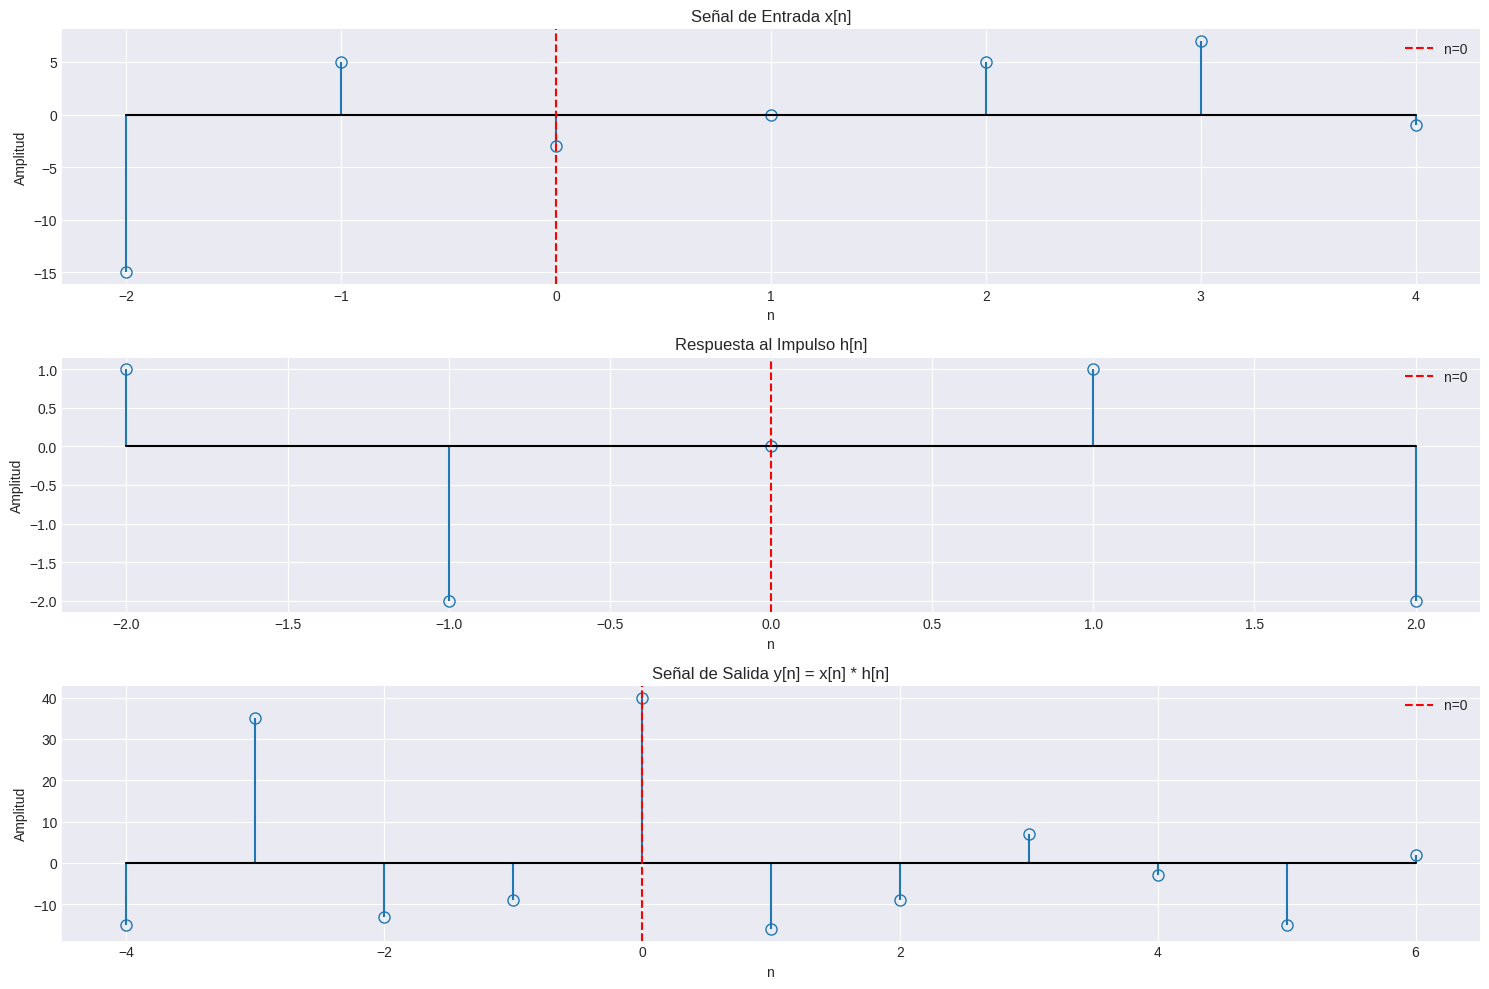



--- Parte 2: Usando Respuesta al Escalón s[n] ---
Respuesta al escalón s[n]: [ -1   6 -10   3   1 -10   2   5]
Índices n_s: [-3 -2 -1  0  1  2  3  4]

Nueva respuesta al impulso h_2[n]: [ -1   7 -16  13  -2 -11  12   3  -5]
Índices n_h2: [-3 -2 -1  0  1  2  3  4  5]

Señal de salida y_2[n]: [  15 -110  278 -296  138  144 -259   -6  151 -116    0  110  -16  -38
    5]
Índices n_y2: [-5 -4 -3 -2 -1  0  1  2  3  4  5  6  7  8  9]


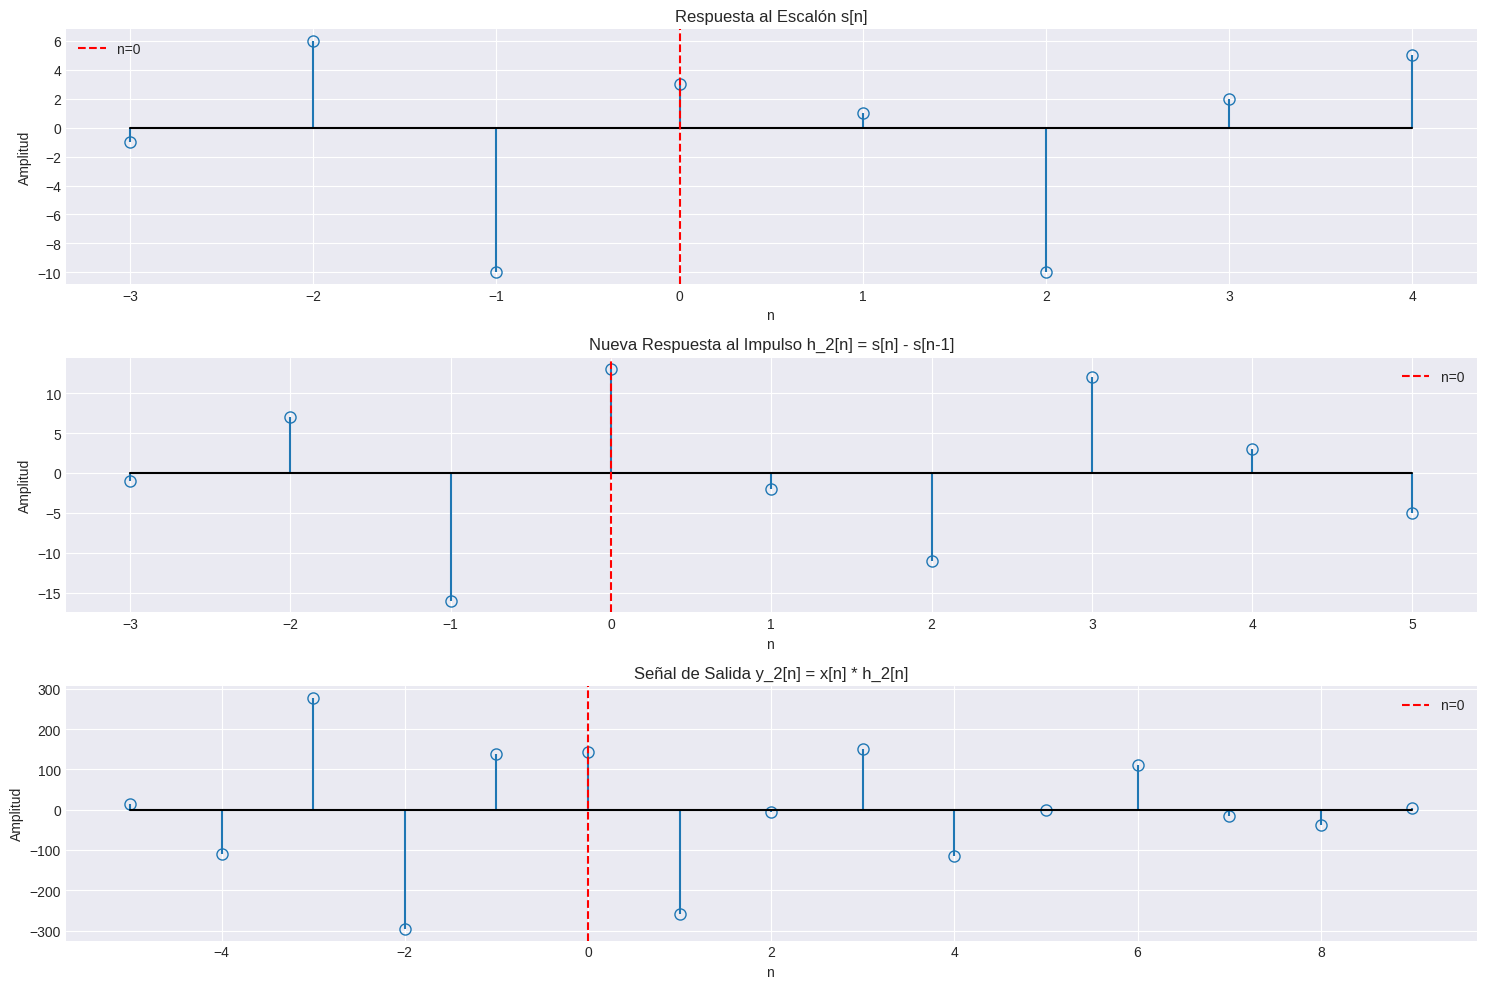

In [20]:
# ═══════════════════════════════════════════════════════════════════════════
# IMPORTS - Librerías necesarias para procesamiento de señales y gráficas
# ═══════════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt

# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN DE GRÁFICOS - Estilo y parámetros para visualización
# ═══════════════════════════════════════════════════════════════════════════
# Esto hará que los gráficos se vean mejor en Colab
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['markers.fillstyle'] = 'none'
plt.rcParams['lines.markersize'] = 8

# ═══════════════════════════════════════════════════════════════════════════
# FUNCIÓN AUXILIAR - Graficar señales discretas con formato stem
# ═══════════════════════════════════════════════════════════════════════════
def plot_signal(n, x, title, ax):
    """Función para graficar señales discretas con stem."""
    ax.stem(n, x, linefmt='C0-', markerfmt='C0o', basefmt='k-')
    ax.set_xlabel('n')
    ax.set_ylabel('Amplitud')
    ax.set_title(title)
    ax.grid(True)
    # Marcar el origen (n=0)
    ax.axvline(0, color='r', linestyle='--', linewidth=1.5, label='n=0')
    ax.legend()

# ═══════════════════════════════════════════════════════════════════════════
# PARTE 1: CONVOLUCIÓN CON h[n] - Cálculo directo de la convolución
# ═══════════════════════════════════════════════════════════════════════════
print("--- Parte 1: y[n] = x[n] * h[n] ---")

# ────────────────────────────────────────────────────────────────────────
# DEFINICIÓN DE SEÑALES - Crear las señales de entrada y respuesta al impulso
# ────────────────────────────────────────────────────────────────────────
x = np.array([-15, 5, -3, 0, 5, 7, -1])
n_x = np.arange(-2, 5) # n = -2 hasta n = 4 (7 muestras)

h = np.array([1, -2, 0, 1, -2])
n_h = np.arange(-2, 3) # n = -2 hasta n = 2 (5 muestras)

# ────────────────────────────────────────────────────────────────────────
# CÁLCULO DE CONVOLUCIÓN - Aplicar la operación de convolución
# ────────────────────────────────────────────────────────────────────────
# 'full' calcula la convolución completa
y = np.convolve(x, h, mode='full')

# ────────────────────────────────────────────────────────────────────────
# CÁLCULO DE ÍNDICES - Determinar el rango de índices para la salida
# ────────────────────────────────────────────────────────────────────────
n_y_start = n_x[0] + n_h[0]
n_y_end = n_x[-1] + n_h[-1]
n_y = np.arange(n_y_start, n_y_end + 1)

# ────────────────────────────────────────────────────────────────────────
# MOSTRAR RESULTADOS - Imprimir las señales y sus índices
# ────────────────────────────────────────────────────────────────────────
print(f"Señal x[n]: {x}")
print(f"Índices n_x: {n_x}\n")
print(f"Señal h[n]: {h}")
print(f"Índices n_h: {n_h}\n")
print(f"Señal de salida y[n]: {y}")
print(f"Índices n_y: {n_y}")

# ────────────────────────────────────────────────────────────────────────
# VISUALIZACIÓN - Graficar las señales de entrada, impulso y salida
# ────────────────────────────────────────────────────────────────────────
fig1, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 10))
plot_signal(n_x, x, 'Señal de Entrada x[n]', ax1)
plot_signal(n_h, h, 'Respuesta al Impulso h[n]', ax2)
plot_signal(n_y, y, 'Señal de Salida y[n] = x[n] * h[n]', ax3)
fig1.tight_layout()
plt.show()


# ═══════════════════════════════════════════════════════════════════════════
# PARTE 2: CONVOLUCIÓN CON RESPUESTA AL ESCALÓN - Usar s[n] para obtener h[n]
# ═══════════════════════════════════════════════════════════════════════════
print("\n\n--- Parte 2: Usando Respuesta al Escalón s[n] ---")

# ────────────────────────────────────────────────────────────────────────
# DEFINICIÓN DE RESPUESTA AL ESCALÓN - Crear la señal s[n]
# ────────────────────────────────────────────────────────────────────────
s = np.array([-1, 6, -10, 3, 1, -10, 2, 5])
n_s = np.arange(-3, 5) # n = -3 hasta n = 4 (8 muestras)

# ────────────────────────────────────────────────────────────────────────
# CÁLCULO DE RESPUESTA AL IMPULSO - Obtener h_2[n] = s[n] - s[n-1]
# ────────────────────────────────────────────────────────────────────────
# Usamos np.diff con prepend=0 y append=0 para manejar los bordes
# h[n] = s[n] - s[n-1]
# Asumimos s[n] = 0 fuera del rango [-3, 4]
# Esta es la forma correcta de hacerlo asumiendo s=0 fuera del rango:
h2 = np.diff(s, prepend=0, append=0)

# El vector de índices para h2 comienza en el mismo lugar que s
n_h2_start = n_s[0]
n_h2 = np.arange(n_h2_start, n_h2_start + len(h2))

print(f"Respuesta al escalón s[n]: {s}")
print(f"Índices n_s: {n_s}\n")
print(f"Nueva respuesta al impulso h_2[n]: {h2}")
print(f"Índices n_h2: {n_h2}\n")

# ────────────────────────────────────────────────────────────────────────
# CÁLCULO DE CONVOLUCIÓN - Aplicar convolución con la nueva respuesta
# ────────────────────────────────────────────────────────────────────────
y2 = np.convolve(x, h2, mode='full')

# ────────────────────────────────────────────────────────────────────────
# CÁLCULO DE ÍNDICES - Determinar el rango de índices para la salida
# ────────────────────────────────────────────────────────────────────────
n_y2_start = n_x[0] + n_h2[0]
n_y2_end = n_x[-1] + n_h2[-1]
n_y2 = np.arange(n_y2_start, n_y2_end + 1)

# ────────────────────────────────────────────────────────────────────────
# MOSTRAR RESULTADOS - Imprimir las señales y sus índices
# ────────────────────────────────────────────────────────────────────────
print(f"Señal de salida y_2[n]: {y2}")
print(f"Índices n_y2: {n_y2}")

# ────────────────────────────────────────────────────────────────────────
# VISUALIZACIÓN - Graficar escalón, impulso derivado y salida
# ────────────────────────────────────────────────────────────────────────
fig2, (ax4, ax5, ax6) = plt.subplots(3, 1, figsize=(15, 10))
plot_signal(n_s, s, 'Respuesta al Escalón s[n]', ax4)
plot_signal(n_h2, h2, 'Nueva Respuesta al Impulso h_2[n] = s[n] - s[n-1]', ax5)
plot_signal(n_y2, y2, 'Señal de Salida y_2[n] = x[n] * h_2[n]', ax6)
fig2.tight_layout()
plt.show()

## Punto 2.5

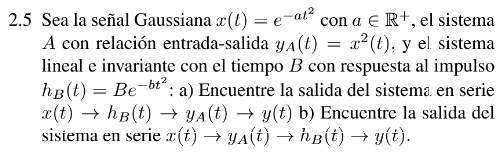

  * **Señal de entrada:** $x(t) = e^{-at^2}$ (con $a \in \mathbb{R}^+$)
  * **Sistema A (No lineal):** $y_A(t) = x^2(t)$ (Eleva la entrada al cuadrado)
  * **Sistema B (LTI):** Respuesta al impulso $h_B(t) = Be^{-bt^2}$

-----

### a) Salida del sistema:
$x(t) \rightarrow [Sistema B] \rightarrow [Sistema A] \rightarrow y(t)$

En esta configuración, primero aplicamos el sistema LTI (convolución) y luego el sistema no lineal (cuadrado).

### Paso 1: Salida del Sistema B

Llamemos $v(t)$ a la salida del Sistema B. Al ser un sistema LTI, la salida es la convolución de la entrada $x(t)$ con la respuesta al impulso $h_B(t)$.

$$v(t) = x(t) * h_B(t) = \int_{-\infty}^{\infty} x(\tau) h_B(t - \tau) d\tau$$
$$v(t) = \int_{-\infty}^{\infty} e^{-a\tau^2} \cdot Be^{-b(t-\tau)^2} d\tau$$

Esta es la convolución de dos señales Gaussianas. Usamos la propiedad conocida de la convolución de Gaussianas:
*Si $g_1(t) = A_1 e^{-k_1 t^2}$ y $g_2(t) = A_2 e^{-k_2 t^2}$, entonces:*
$$g_1(t) * g_2(t) = A_1 A_2 \sqrt{\frac{\pi}{k_1 + k_2}} e^{-\frac{k_1 k_2}{k_1 + k_2} t^2}$$

Para nuestro caso:

  * $A_1 = 1$, $k_1 = a$
  * $A_2 = B$, $k_2 = b$

Aplicando la fórmula:
$$v(t) = (1 \cdot B) \sqrt{\frac{\pi}{a + b}} e^{-\frac{ab}{a + b} t^2}$$
$$v(t) = B \sqrt{\frac{\pi}{a + b}} e^{-\frac{ab}{a + b} t^2}$$

### Paso 2: Salida del Sistema A

La salida final $y(t)$ es la salida del Sistema A, que toma $v(t)$ como entrada y la eleva al cuadrado.

$$y(t) = [v(t)]^2 = \left( B \sqrt{\frac{\pi}{a + b}} e^{-\frac{ab}{a + b} t^2} \right)^2$$
$$y(t) = B^2 \left( \frac{\pi}{a + b} \right) \left( e^{-\frac{ab}{a + b} t^2} \right)^2$$

**La solución para el inciso (a) es:**
$$y(t) = \frac{B^2 \pi}{a + b} e^{-\frac{2ab}{a + b} t^2}$$

-----

## b) Salida del sistema: $x(t) \rightarrow [Sistema A] \rightarrow [Sistema B] \rightarrow y(t)$

En esta configuración, primero aplicamos el sistema no lineal (cuadrado) y luego el sistema LTI (convolución).

### Paso 1: Salida del Sistema A

Llamemos $w(t)$ a la salida del Sistema A. Este sistema eleva la entrada $x(t)$ al cuadrado.

$$w(t) = [x(t)]^2 = (e^{-at^2})^2$$
$$w(t) = e^{-2at^2}$$

### Paso 2: Salida del Sistema B

La salida final $y(t)$ es la salida del Sistema B, que toma $w(t)$ como entrada. La salida es la convolución $w(t) * h_B(t)$.

$$y(t) = w(t) * h_B(t) = (e^{-2at^2}) * (Be^{-bt^2})$$

Nuevamente, usamos la fórmula de convolución de Gaussianas con:

  * $A_1 = 1$, $k_1 = 2a$
  * $A_2 = B$, $k_2 = b$

Aplicando la fórmula:
$$y(t) = (1 \cdot B) \sqrt{\frac{\pi}{2a + b}} e^{-\frac{(2a)b}{2a + b} t^2}$$

**La solución para el inciso (b) es:**
$$y(t) = B \sqrt{\frac{\pi}{2a + b}} e^{-\frac{2ab}{2a + b} t^2}$$

Salida del sistema (a): x → B → A


              2 
      -2⋅a⋅b⋅t  
      ──────────
   2    a + b   
π⋅B ⋅ℯ          
────────────────
     a + b      

Salida del sistema (b): x → A → B


              2 
      -2⋅a⋅b⋅t  
      ──────────
       2⋅a + b  
√π⋅B⋅ℯ          
────────────────
    _________   
  ╲╱ 2⋅a + b    

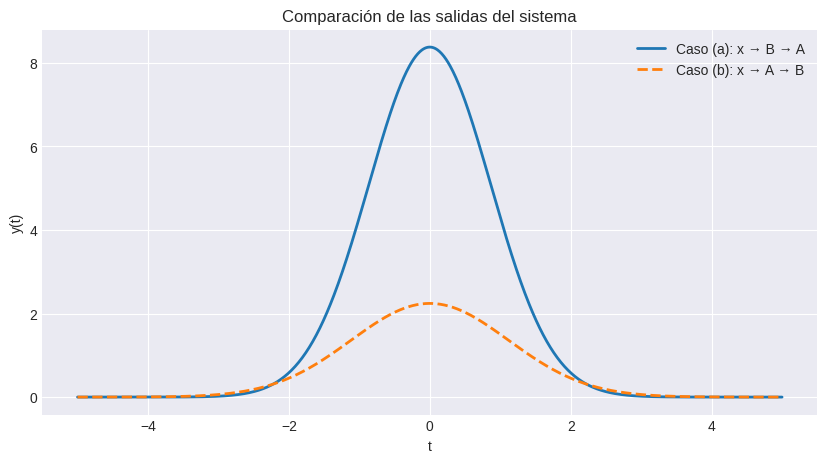

Prefactor caso (a): 8.3776
Prefactor caso (b): 2.2420


In [26]:
# ═══════════════════════════════════════════════════════════════════════════
# IMPORTS - Librerías necesarias para cálculo simbólico y gráficas
# ═══════════════════════════════════════════════════════════════════════════
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# ═══════════════════════════════════════════════════════════════════════════
# VARIABLES SIMBÓLICAS - Definición de variables para cálculo simbólico
# ═══════════════════════════════════════════════════════════════════════════
t, a, b, B = sp.symbols('t a b B', positive=True)

# ═══════════════════════════════════════════════════════════════════════════
# CASO (a): x(t) → Sistema B → Sistema A
# ═══════════════════════════════════════════════════════════════════════════
# v(t) = x * hB = B * sqrt(pi/(a+b)) * exp(-(a*b)/(a+b) * t^2)
v_t = B * sp.sqrt(sp.pi / (a + b)) * sp.exp(-a * b / (a + b) * t**2)

# y(t) = [v(t)]^2
y_a = sp.simplify(v_t**2)
y_a

# ═══════════════════════════════════════════════════════════════════════════
# CASO (b): x(t) → Sistema A → Sistema B
# ═══════════════════════════════════════════════════════════════════════════
# w(t) = x^2(t) = e^{-2 a t^2}
# y(t) = w * hB = B * sqrt(pi/(2a+b)) * exp(-(2ab)/(2a+b) * t^2)
y_b = B * sp.sqrt(sp.pi / (2 * a + b)) * sp.exp(-2 * a * b / (2 * a + b) * t**2)
y_b

# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN SIMBÓLICA - Mostrar expresiones en formato LaTeX
# ═══════════════════════════════════════════════════════════════════════════
sp.init_printing(use_latex='mathjax')

print("Salida del sistema (a): x → B → A")
display(y_a)

print("Salida del sistema (b): x → A → B")
display(y_b)

# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN NUMÉRICA - Graficar los dos casos con valores de ejemplo
# ═══════════════════════════════════════════════════════════════════════════
# ────────────────────────────────────────────────────────────────────────
# PARÁMETROS NUMÉRICOS - Valores de ejemplo para evaluación
# ────────────────────────────────────────────────────────────────────────
aval = 1.0   # a > 0
bval = 0.5   # b > 0
Bval = 2.0   # constante B

# ────────────────────────────────────────────────────────────────────────
# CONVERSIÓN A FUNCIONES NUMÉRICAS - Convertir expresiones simbólicas
# ────────────────────────────────────────────────────────────────────────
y_a_num = sp.lambdify((t, a, b, B), y_a, 'numpy')
y_b_num = sp.lambdify((t, a, b, B), y_b, 'numpy')

# ────────────────────────────────────────────────────────────────────────
# EVALUACIÓN Y GRÁFICA - Calcular valores y visualizar resultados
# ────────────────────────────────────────────────────────────────────────
T = np.linspace(-5, 5, 1001)

Ya = y_a_num(T, aval, bval, Bval)
Yb = y_b_num(T, aval, bval, Bval)

plt.figure(figsize=(10,5))
plt.plot(T, Ya, label='Caso (a): x → B → A', linewidth=2)
plt.plot(T, Yb, '--', label='Caso (b): x → A → B', linewidth=2)
plt.title('Comparación de las salidas del sistema')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.legend()
plt.grid(True)
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# ANÁLISIS DE PREFACTORES - Calcular amplitud en t = 0 para comparación
# ═══════════════════════════════════════════════════════════════════════════
pref_a = float(y_a.subs({t:0, a:aval, b:bval, B:Bval}))
pref_b = float(y_b.subs({t:0, a:aval, b:bval, B:Bval}))

print(f"Prefactor caso (a): {pref_a:.4f}")
print(f"Prefactor caso (b): {pref_b:.4f}")

